In [1]:
import ROOT
import numpy as np
import uproot as ur
import awkward as ak
import matplotlib.pyplot as plt
import mplhep as hep
import os
hep.style.use("CMS")
hep.style.use(hep.style.CMS)
import matplotlib.colors as mcolors
from matplotlib import colormaps
from scipy.optimize import curve_fit
import pandas as pd
from cycler import cycler
plt.rcParams["axes.prop_cycle"] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [2]:
solid_target = "C"
plot_title = "RGE LD2 + C: 20131-20176 pass 0.8"
sim_title = "RGE LD2 + C: clasdis simulation"
E_beam = 10.547
lumonisity_ratios = {"C": .75, "Pb":.5}
target_densities = {"C":(1.688+1.712)/2, "LD2":(.163+.169/2)} # g/cm3
target_thicknesses = {"C":.151, "LD2":2.0} # cm
target_atomic_weights = {"C": 12.1, "LD2":2.014} # g/mol
num_incident_electrons_per_target = {"C":(.032*10**(-3))/(1.602*10**(-19)), "LD2":(.032*10**(-3))/(1.602*10**(-19))}
avogadro = 6.022*10**23
cm_to_pb = 1*10**36
num_sectors=6

In [3]:
separated_sim_liquid_and_solid = True
directories = {"data" : "/media/miguel/Elements_2024/CLAS_data/C/electron_candidates/",
               "sim_liquid" : "/media/miguel/Elements_2024/CLAS_data/C/electron_candidates/",
               "sim_solid" : "/media/miguel/Elements_2024/CLAS_data/C/electron_candidates/",
              }
file_names = {"data" : "electron_candidates_notargetcuts_withfiducialcuts_W2GeVcut_020131-020176_pass07_roottuples.root",
              "sim_liquid" : "electron_candidates_notargetcuts_withfiducialcuts_W2GeVcut_LD2Cliquid_clasdis_deuteron_3000files_roottuples.root",
              "sim_solid" : "electron_candidates_notargetcuts_withfiducialcuts_W2GeVcut_LD2Csolid_clasdis_deuteron_3000files_roottuples.root",
             }

branches_dict = {}
for name in directories:
    with ur.open(f"{os.path.join(directories[name], file_names[name])}:electrons") as events:
        branches = events.arrays()
        permutation = np.random.permutation(len(branches))
        branches_shuffled = branches[permutation]
        branches_dict[name] = branches_shuffled[:]

if separated_sim_liquid_and_solid:
    branches_dict["sim_solid"]["weight"] = 1
    branches_dict["sim_liquid"]["weight"] = 1
    
    n_liquid = len(branches_dict["sim_liquid"]["v_z"])
    branches_dict["sim_liquid"]["target"] = ak.Array(["D2"]*n_liquid)
    n_solid  = len(branches_dict["sim_solid"]["v_z"])
    branches_dict["sim_solid"]["target"] = ak.Array([solid_target]*n_solid)
    branches_dict["sim"] = ak.concatenate([branches_dict["sim_liquid"], branches_dict["sim_solid"]])
else:
    branches_dict["sim"]["weight"] = 1


Text(0.5, 1.0, 'e+A DIS phase-space')

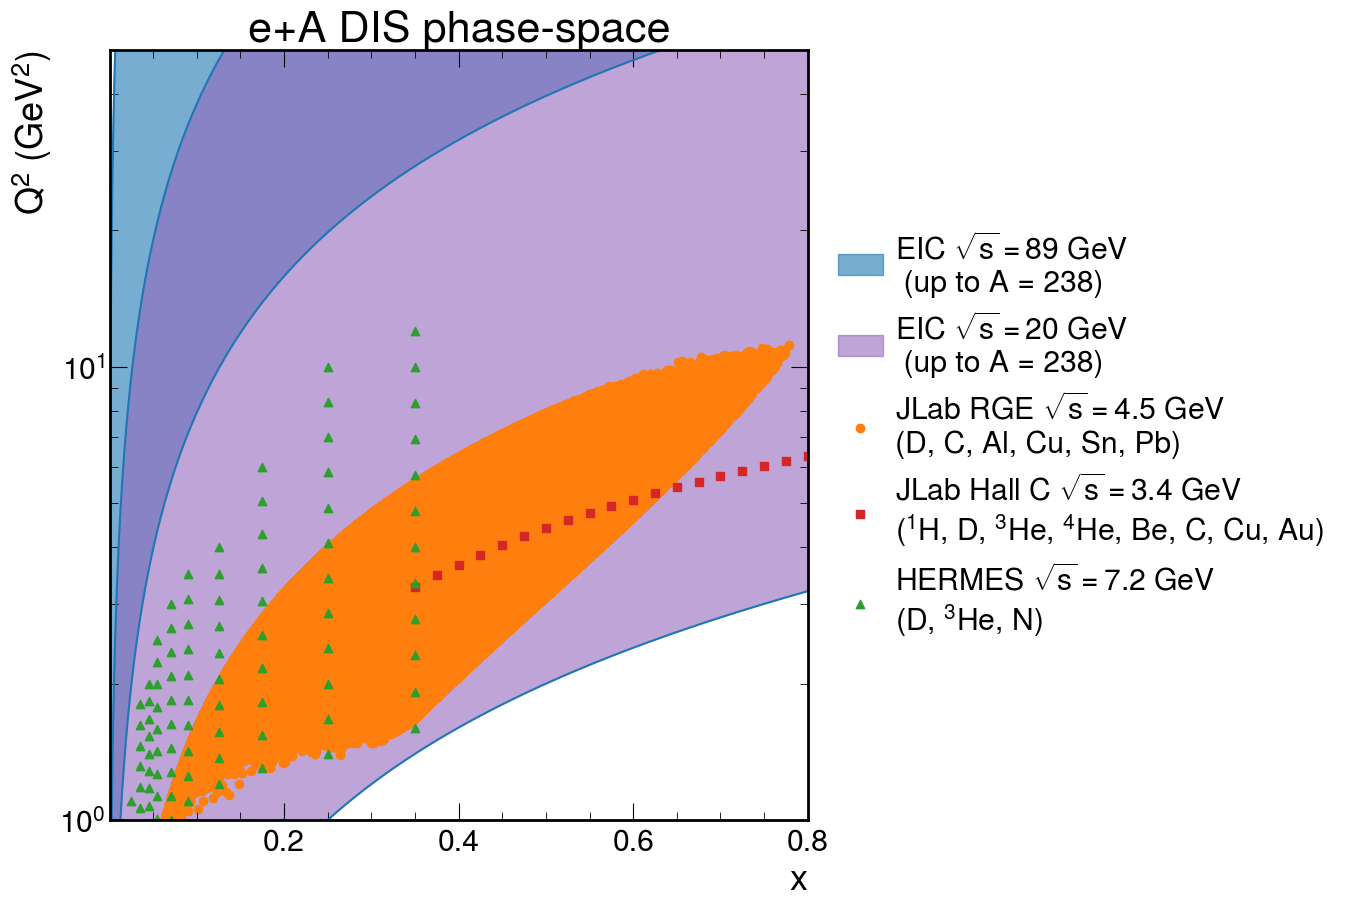

In [4]:
fig = plt.figure(figsize=(12, 10))
ax = plt.gca()

# EIC sqrt s = 89 GeV
s = 89**2 
y_min = 0.01
y_max = .95
x = np.logspace(-4, 0, 500)
Q2_min = x * y_min * s
Q2_max = x * y_max * s
plt.fill_between(x, Q2_min, Q2_max, color='#1f77b4', alpha=0.6, label="EIC $\sqrt{s} = 89$ GeV\n (up to A = 238)")
plt.plot(x, Q2_min, color='#1f77b4')
plt.plot(x, Q2_max, color='#1f77b4')

# EIC sqrt s = 20 GeV
s = 20**2 
Q2_min = x * y_min * s
Q2_max = x * y_max * s
plt.fill_between(x, Q2_min, Q2_max, color='#9467bd', alpha=0.6, label="EIC $\sqrt{s} = 20$ GeV\n (up to A = 238)")
plt.plot(x, Q2_min, color='#1f77b4')
plt.plot(x, Q2_max, color='#1f77b4')

hermes_x = [.0125, .0175, .025, .035, .045, .055, .07, .09, .125, .175, .25, .35]
hermes_Q2 = [
    np.logspace(np.log10(0.3),  np.log10(0.5),  4),
    np.logspace(np.log10(0.45), np.log10(0.8),  5),
    np.logspace(np.log10(0.5),  np.log10(1.1),  8),
    np.logspace(np.log10(0.7),  np.log10(1.8),  10),
    np.logspace(np.log10(0.9),  np.log10(2),    10),
    np.logspace(np.log10(0.9),  np.log10(2.5),  10),
    np.logspace(np.log10(1),    np.log10(3),    10),
    np.logspace(np.log10(1.1),  np.log10(3.5),  10),
    np.logspace(np.log10(1.2),  np.log10(4),    10),
    np.logspace(np.log10(1.3),  np.log10(6),    10),
    np.logspace(np.log10(1.4),  np.log10(10),   12),
    np.logspace(np.log10(1.6),  np.log10(12),   12)
]

x_vals = []
q2_vals = []

for x, q2_range in zip(hermes_x, hermes_Q2):
    x_vals.extend([x] * len(q2_range))
    q2_vals.extend(q2_range)

plt.scatter(branches_dict["data"]["x"], branches_dict["data"]["Q2"], label="JLab RGE $\sqrt{s} = 4.5$ GeV\n(D, C, Al, Cu, Sn, Pb) ", color='#ff7f0e')
jlab_6gev_data=np.array([[3.500E-1, 3.266E+0, 8.625E-1, 1.006E+0, 1.034E-2, 1.143E-2],
[3.750E-1, 3.466E+0, 8.541E-1, 9.807E-1, 8.507E-3, 1.105E-2],
[4.000E-1, 3.661E+0, 8.459E-1, 9.751E-1, 9.586E-3, 1.089E-2],
[4.250E-1, 3.853E+0, 8.378E-1, 9.721E-1, 6.011E-3, 1.077E-2],
[4.500E-1, 4.041E+0, 8.299E-1, 9.778E-1, 8.015E-3, 1.075E-2],
[4.750E-1, 4.225E+0, 8.221E-1, 9.779E-1, 7.579E-3, 1.076E-2],
[5.000E-1, 4.406E+0, 8.145E-1, 9.541E-1, 5.835E-3, 1.077E-2],
[5.250E-1, 4.584E+0, 8.070E-1, 9.361E-1, 5.704E-3, 1.077E-2],
[5.500E-1, 4.759E+0, 7.997E-1, 9.347E-1, 5.966E-3, 1.086E-2],
[5.750E-1, 4.930E+0, 7.924E-1, 9.250E-1, 7.195E-3, 1.079E-2],
[6.000E-1, 5.098E+0, 7.853E-1, 9.244E-1, 5.292E-3, 1.076E-2],
[6.250E-1, 5.264E+0, 7.784E-1, 9.244E-1, 6.667E-3, 1.070E-2],
[6.500E-1, 5.426E+0, 7.715E-1, 9.023E-1, 9.596E-3, 1.039E-2],
[6.750E-1, 5.586E+0, 7.648E-1, 9.071E-1, 8.462E-3, 1.040E-2],
[7.000E-1, 5.743E+0, 7.582E-1, 9.047E-1, 9.134E-3, 1.032E-2],
[7.250E-1, 5.897E+0, 7.517E-1, 8.985E-1, 1.006E-2, 1.021E-2],
[7.500E-1, 6.049E+0, 7.453E-1, 9.120E-1, 6.692E-3, 1.032E-2],
[7.750E-1, 6.198E+0, 7.391E-1, 9.301E-1, 1.067E-2, 1.050E-2],
[8.000E-1, 6.344E+0, 7.329E-1, 9.367E-1, 1.169E-2, 1.053E-2],
[8.250E-1, 6.488E+0, 7.268E-1, 9.833E-1, 1.349E-2, 1.103E-2],
[8.500E-1, 6.630E+0, 7.209E-1, 1.020E+0, 1.552E-2, 1.142E-2],
[8.750E-1, 6.769E+0, 7.150E-1, 1.123E+0, 1.589E-2, 1.254E-2],
[9.000E-1, 6.907E+0, 7.092E-1, 1.169E+0, 2.385E-2, 1.303E-2],
[9.250E-1, 7.042E+0, 7.035E-1, 1.277E+0, 1.887E-2, 1.421E-2],
[9.500E-1, 7.174E+0, 6.979E-1, 1.361E+0, 4.168E-2, 1.512E-2]])
jlab_6gev_x = jlab_6gev_data[:,0]
jlab_6gev_Q2 = jlab_6gev_data[:,1]
#sqrt s = 3.4 GeV
plt.scatter(jlab_6gev_x, jlab_6gev_Q2, color='#d62728', marker='s', label='JLab Hall C $\sqrt{s} = 3.4$ GeV\n($^1H$, D, $^3He$, $^4He$, Be, C, Cu, Au)')

#sqrt s = 7.2 GeV
plt.scatter(x_vals, q2_vals, color='#2ca02c', marker='^', label='HERMES $\sqrt{s} = 7.2$ GeV\n(D, $^3He$, N)')




box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.75, box.height])  # shrink width to 75%

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), handletextpad=0.4)

# Final formatting
ax.set_yscale('log')
ax.set_xlim(0.001, 0.8)
ax.set_ylim(1, 50)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$Q^2$ (GeV$^2$)')
ax.set_title("e+A DIS phase-space")


Text(0.5, 1.0, 'RGE LD2 + C: 20131-20176 pass 0.8')

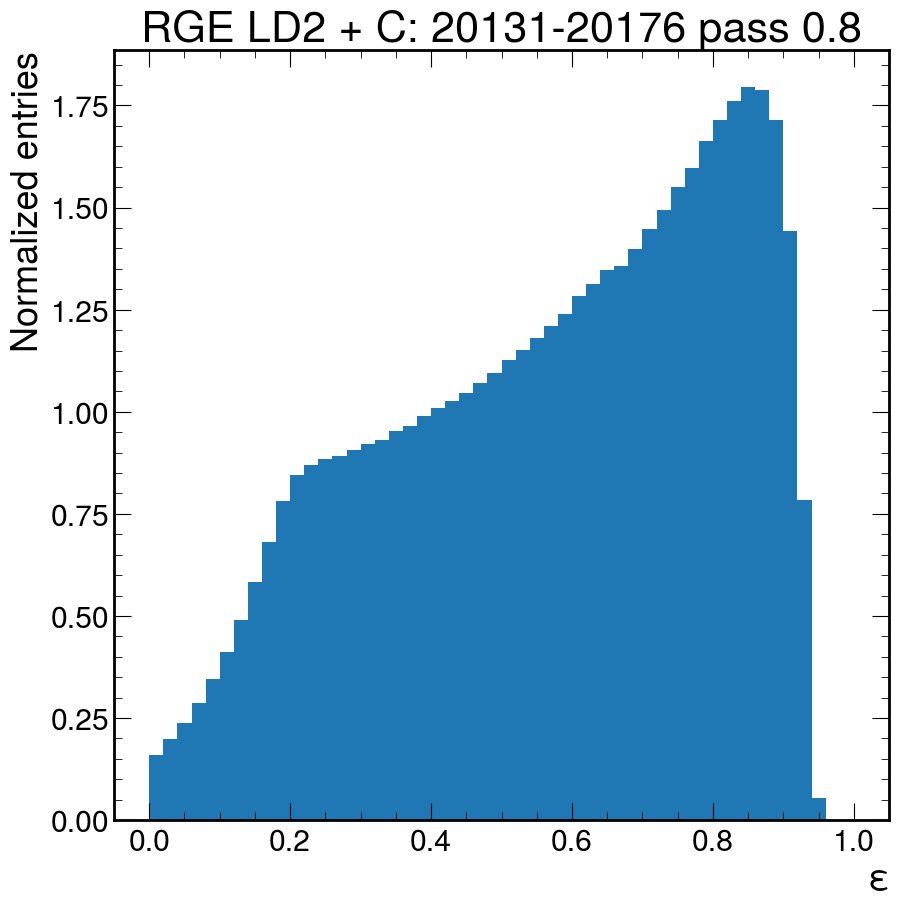

In [5]:
epsilon_numerator = 4*(1-branches_dict["data"]["y"]) - branches_dict["data"]["Q2"]/branches_dict["data"]["p"]**2
epsilon_denominator = 4*(1-branches_dict["data"]["y"]) + 2*branches_dict["data"]["y"]**2 + branches_dict["data"]["Q2"]/branches_dict["data"]["p"]**2
epsilon = epsilon_numerator/epsilon_denominator

plt.hist(epsilon, range = (0,1), bins=50, density=True)
epsilon_numerator = 4*(1-branches_dict["sim"]["y"]) - branches_dict["sim"]["Q2"]/branches_dict["sim"]["p"]**2
epsilon_denominator = 4*(1-branches_dict["sim"]["y"]) + 2*branches_dict["sim"]["y"]**2 + branches_dict["sim"]["Q2"]/branches_dict["sim"]["p"]**2
epsilon = epsilon_numerator/epsilon_denominator
plt.xlabel("$\epsilon$")
plt.ylabel("Normalized entries")
plt.title(plot_title)

### Getting unfolding weights

In [6]:
variables_to_unfold = ["v_z", "p", "theta_degrees", "phi_degrees", "x", "Q2"]
sim_MCreco_dict, sim_MCgen_dict =  {}, {}
for variable in variables_to_unfold:
    sim_MCreco_dict[variable] = np.array(branches_dict["sim"][variable])
    sim_MCgen_dict[variable] = np.array(branches_dict["sim"][variable])
df_MCgen_test = ROOT.RDF.FromNumpy(sim_MCgen_dict)
df_MCreco_test = ROOT.RDF.FromNumpy(sim_MCgen_dict)

In [7]:
def np_to_TVector(array):
    vector = ROOT.TVector(len(array))
    for i, entry in enumerate(array):
        vector[i] = entry
    return vector
def TVector_to_np(vector):
    out_array = []
    for i in range(vector.GetNoElements()):
        out_array.append(vector[i])
    return np.array(out_array)

In [8]:
# unbinned_unfolding = ROOT.RooUnfoldOmnifold()
# unbinned_unfolding.SetSaveDirectory("/home/ryan/clas_analysis/clas12-rge-analysis/analysis/")
# unbinned_unfolding.SetModelName("RGE_carbon_roottuples_withfiducialcuts_W2GeV_pass08")
# unbinned_unfolding.SetTestMCgenDataFrame(df_MCgen_test)
# unbinned_unfolding.SetTestMCrecoDataFrame(df_MCreco_test)
# test_unbinned_results = unbinned_unfolding.TestUnbinnedOmnifold()
# step1_test_weights_TVector = ROOT.std.get[0](test_unbinned_results)
# step2_test_weights_TVector = ROOT.std.get[1](test_unbinned_results)
# step1_weights = TVector_to_np(step1_test_weights_TVector)
# branches_dict["sim"]["step1_weights"] = step1_weights

In [9]:
# plt.hist(branches_dict["sim"]["step1_weights"], bins=50, range=(0,2), density=True)
# plt.xlabel("Step 1 weights")
# plt.title("Sim both targets")

### Selecting the targets from the data

In [10]:
def double_gaussian(x, amp1, mean1, sigma1, amp2, mean2, sigma2):
    return amp1 * np.exp( -(x - mean1)**2 / (2*sigma1) ) + \
           amp2 * np.exp( -(x - mean2)**2 / (2*sigma2) )

28585.0
26853.0
28085.0
28233.0
26623.0
29084.0


Text(0.5, 1.02, 'RGE LD2 + C: 20131-20176 pass 0.8\n Electron candidates with vx,vy cut')

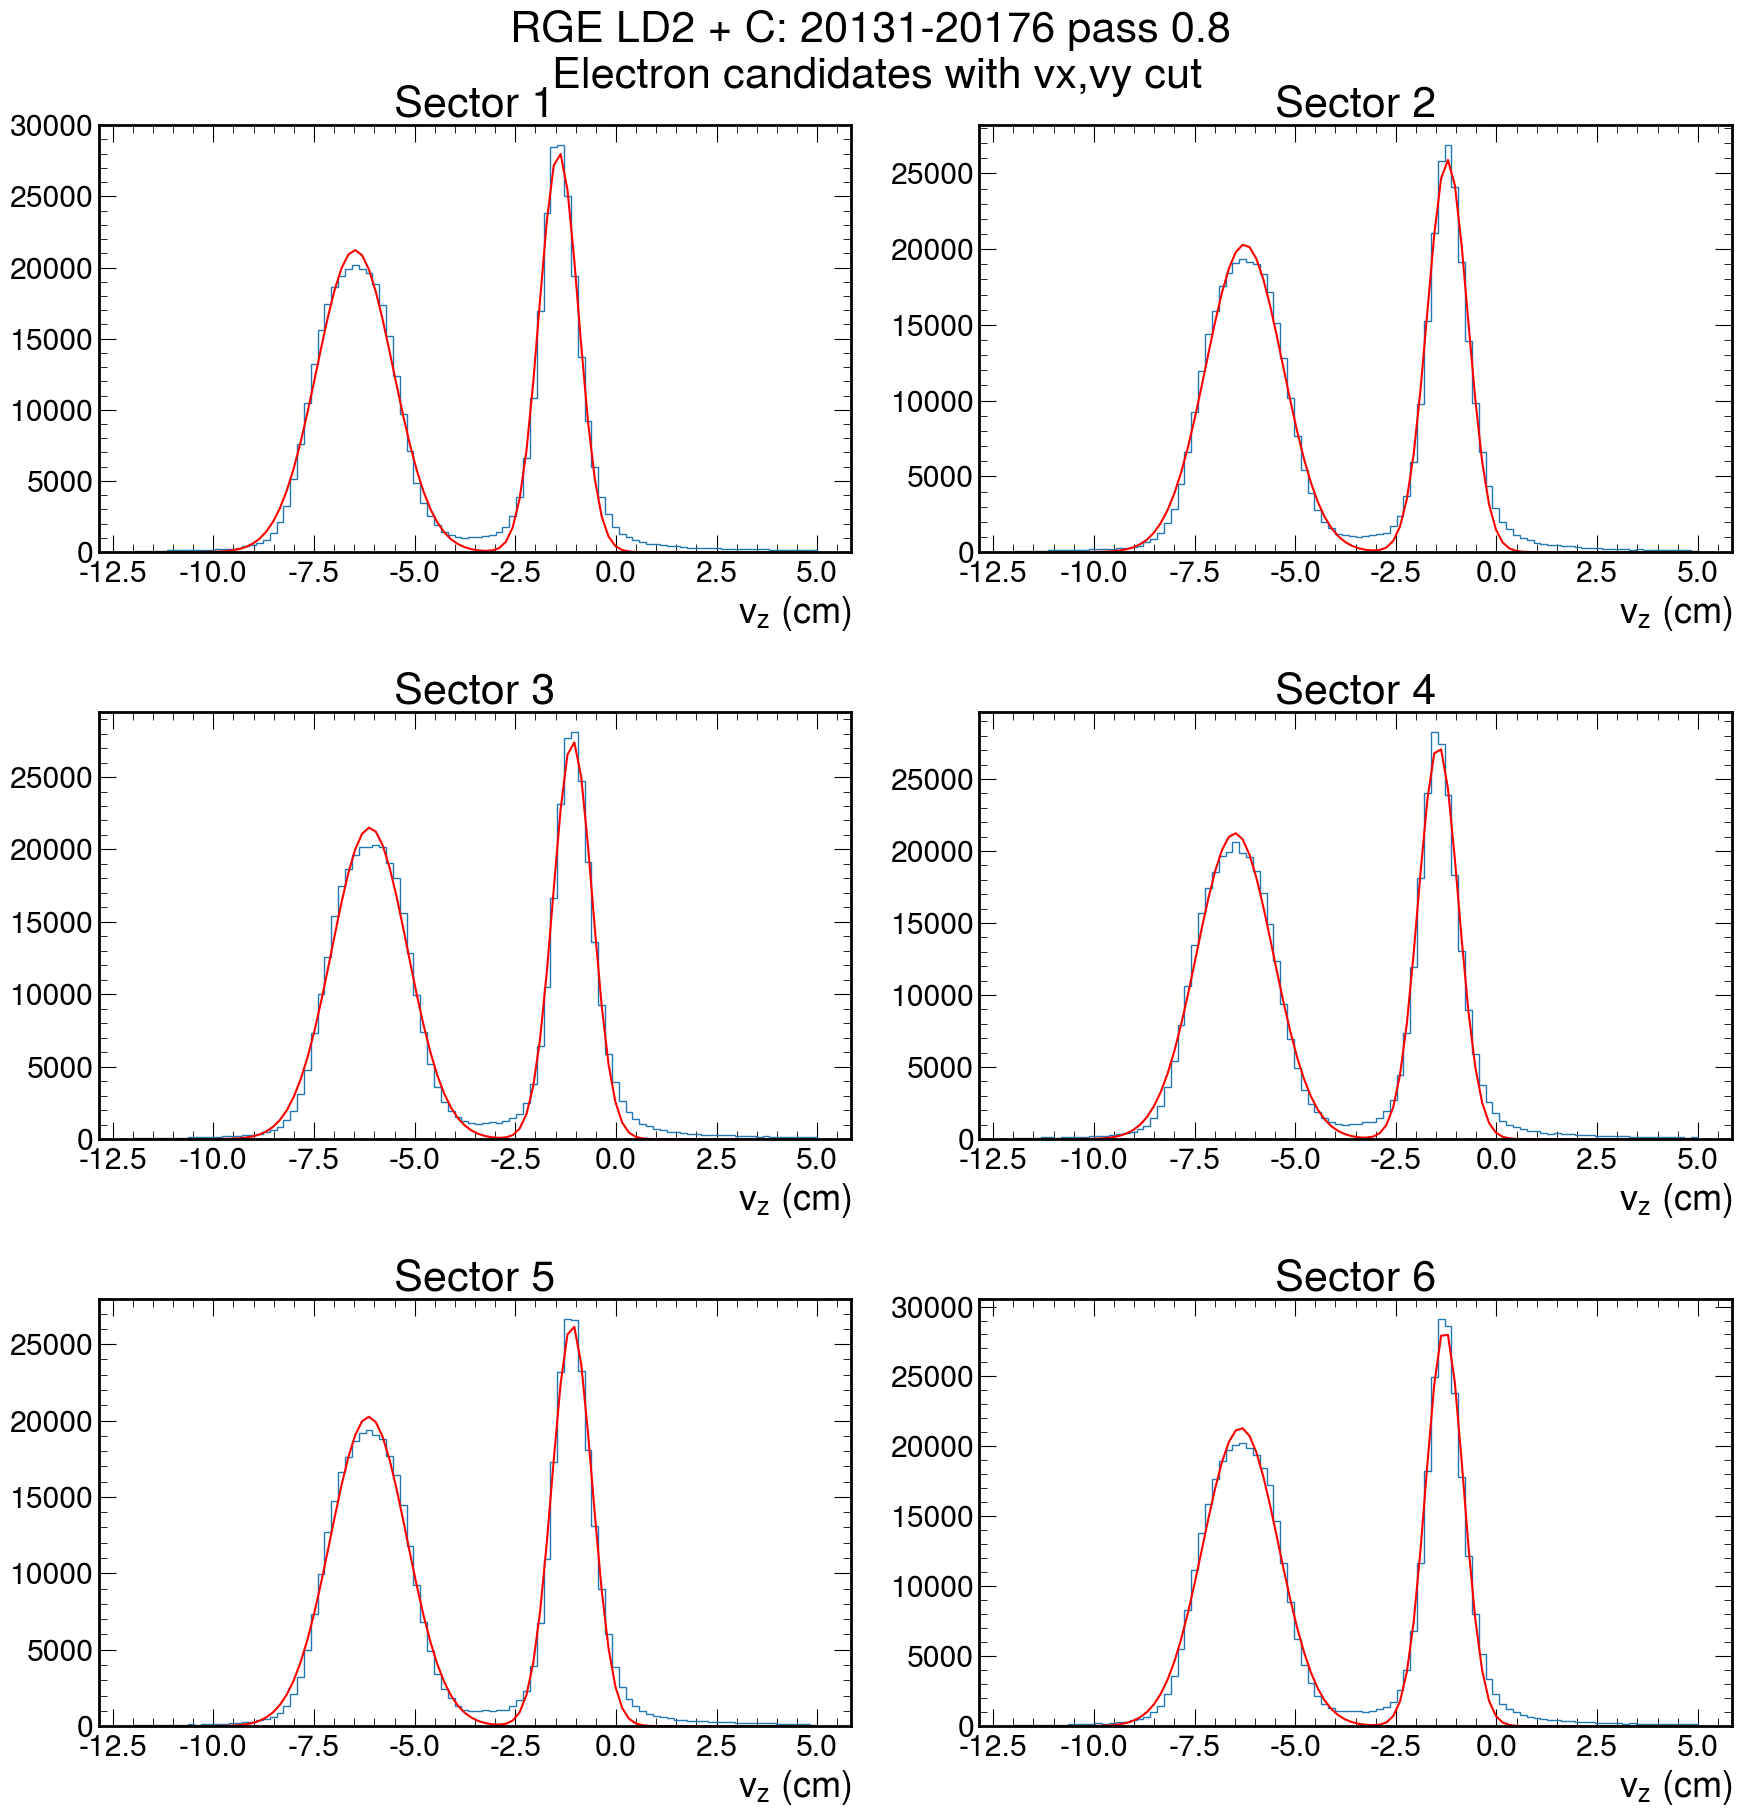

In [11]:
fig, axs = plt.subplots(3, 2, figsize=(18, 18))
axs = axs.flatten()
num_sectors = 6
z_fit_parameters_all_sectors = []
for sector in range(num_sectors):
    sector_cut = branches_dict["data"]["sector"]==(sector+1)
    
    vertex_z = np.array(branches_dict["data"]["v_z"][sector_cut])
    vertex_z_counts, vertex_z_bins, _ = axs[sector].hist(
        vertex_z,
        bins=100,
        range=(-12,5),
        histtype='step'
    )
    vertex_z_bin_centers = (vertex_z_bins[:-1] + vertex_z_bins[1:])/2
    lower_fit_range = -12
    upper_fit_range = 12

    amplitude_guess = np.max(vertex_z_counts)
    mean_z_guess = ak.mean(vertex_z)
    std_z_guess = ak.std(vertex_z)
    
    print(amplitude_guess)
    z_fit_parameters, z_fit_covariance = curve_fit(double_gaussian,
                                                   vertex_z_bin_centers,
                                                   vertex_z_counts, 
                                                   p0=(amplitude_guess, -7, 2.5, amplitude_guess, -1.5, 1.5))
    y_fit = double_gaussian(vertex_z_bin_centers, *z_fit_parameters)
    z_fit_parameters_all_sectors.append(z_fit_parameters)
    axs[sector].plot(vertex_z_bin_centers, y_fit, color='r')
    axs[sector].set_xlabel("$v_{z}$ (cm)")
    axs[sector].set_title(f"Sector {sector+1}") 
    
fig.tight_layout()
fig.suptitle(plot_title+"\n Electron candidates with vx,vy cut", y=1.02)

[ 2.12268657e+04 -6.48234007e+00  9.01675823e-01  2.80947228e+04
 -1.42001534e+00  2.35224776e-01]
[ 2.03102814e+04 -6.25936608e+00  9.15635979e-01  2.58944714e+04
 -1.21794961e+00  2.53684337e-01]
[ 2.15076306e+04 -6.11722809e+00  8.90587634e-01  2.74903308e+04
 -1.07545591e+00  2.37501492e-01]
[ 2.12335889e+04 -6.49745068e+00  9.06713335e-01  2.73203597e+04
 -1.44524756e+00  2.49070869e-01]
[ 2.02484766e+04 -6.14349960e+00  9.05313935e-01  2.62974298e+04
 -1.09154403e+00  2.50353996e-01]
[ 2.13233405e+04 -6.35319237e+00  8.86836545e-01  2.84043833e+04
 -1.28747244e+00  2.20911971e-01]


Text(0.5, 1.02, 'RGE LD2 + C: 20131-20176 pass 0.8')

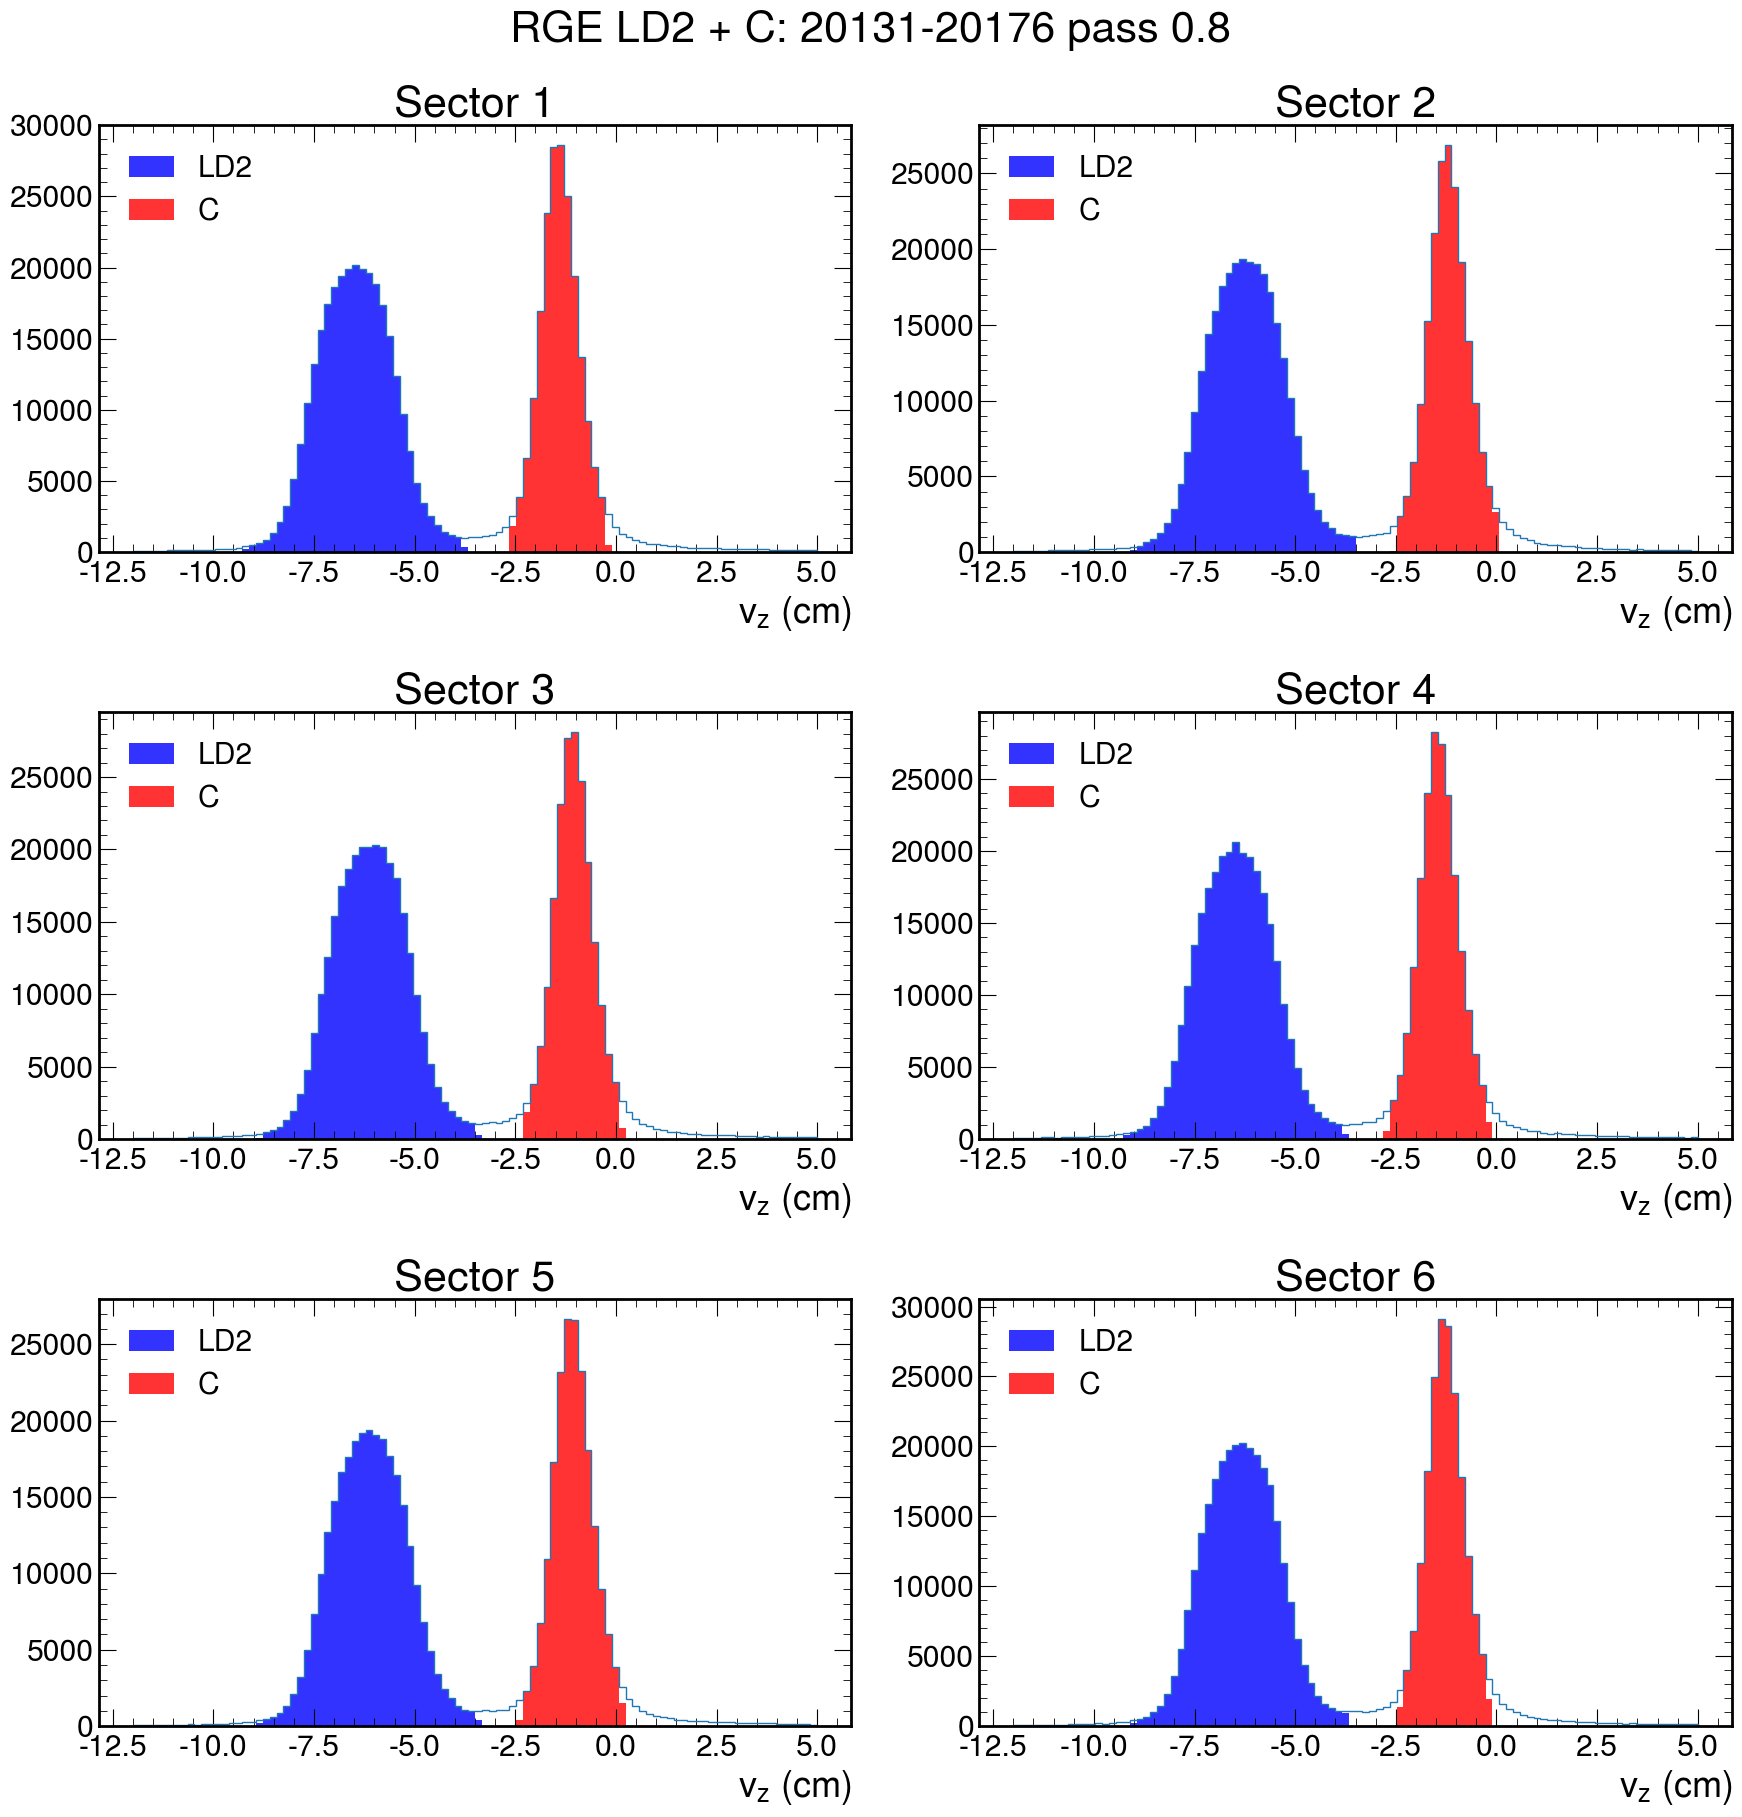

In [12]:
deuterium_mask_by_sector = []
solid_mask_by_sector = []
fig, axs = plt.subplots(3, 2, figsize=(18, 18))
axs = axs.flatten()
for sector in range(num_sectors):
    z_fit_parameters = z_fit_parameters_all_sectors[sector]
    print(z_fit_parameters)
    sector_cut = branches_dict["data"]["sector"]==(sector+1)
    
    vertex_z = np.array(branches_dict["data"]["v_z"][sector_cut])
    vertex_z_counts, vertex_z_bins, _ = axs[sector].hist(
        vertex_z,
        bins=100,
        range=(-12,5),
        histtype='step'
    )
    vertex_z_bin_centers = (vertex_z_bins[:-1] + vertex_z_bins[1:])/2
    deuterium_z_mean = min(z_fit_parameters[1], z_fit_parameters[4])
    if deuterium_z_mean == z_fit_parameters[1]:
        deuterium_z_sigma = z_fit_parameters[2]
        solid_z_mean, solid_z_sigma = z_fit_parameters[4], z_fit_parameters[5]
    elif deuterium_z_mean == z_fit_parameters[4]:
        deuterium_z_sigma = z_fit_parameters[5]
        solid_z_mean, solid_z_sigma = z_fit_parameters[1], z_fit_parameters[2]
    
    # 2 sigma cut was chosen arbitrarily. Just a first attempt that looks OK.
    deuterium_cut = (vertex_z > (deuterium_z_mean - 3 * deuterium_z_sigma) ) &\
                    (vertex_z < (deuterium_z_mean + 3 * deuterium_z_sigma) )
    solid_cut     = (vertex_z > (solid_z_mean - 5 * solid_z_sigma) ) &\
                    (vertex_z < (solid_z_mean + 5 * solid_z_sigma) )
    deuterium_mask_by_sector.append(deuterium_cut)
    solid_mask_by_sector.append(solid_cut)
    
    axs[sector].hist(vertex_z[deuterium_cut],
         bins = 100,
         range=(-12, 5),
         color='b',
         label="LD2",
         alpha=.8)
    axs[sector].hist(vertex_z[solid_cut],
             bins = 100,
             range=(-12, 5),
             color='r',
             label=solid_target,
             alpha=.8)
    
    axs[sector].set_xlabel("$v_{z}$ (cm)")
    axs[sector].set_title(f"Sector {sector+1}") 
    axs[sector].legend(loc='upper left')
fig.tight_layout()
fig.suptitle(plot_title, y=1.02)

In [13]:
masked_branches_by_sector = []
target_type_by_sector = []
for sector in range(num_sectors):
    sector_mask = branches_dict["data"]["sector"]==(sector+1)
    target_type = []
    for deuterium, solid in zip(deuterium_mask_by_sector[sector], solid_mask_by_sector[sector]):
        if deuterium:
            target_type.append("D2")
        elif solid:
            target_type.append(solid_target)
    target_type_by_sector.append(ak.Array(target_type))
    
    target_mask = (deuterium_mask_by_sector[sector] | solid_mask_by_sector[sector])
    masked_branches =  branches_dict["data"][sector_mask][target_mask]
    masked_branches_by_sector.append(masked_branches)
enriched_by_sector = [
    ak.with_field(data_array, target_array, where="target")
    for data_array, target_array in zip(masked_branches_by_sector, target_type_by_sector)
]
branches_dict["data"] = ak.concatenate(enriched_by_sector)
branches_dict = ak.Record(branches_dict)

In [14]:
solid_data = branches_dict["data"][branches_dict["data"]["target"] == solid_target]
deuterium_data = branches_dict["data"][branches_dict["data"]["target"] == "D2"]

dataframes = {}

dataframes[solid_target] =  ak.to_dataframe(solid_data)
dataframes["LD2"] =  ak.to_dataframe(deuterium_data)

sim_solid_data = branches_dict["sim"][branches_dict["sim"]["target"] == solid_target]
sim_deuterium_data = branches_dict["sim"][branches_dict["sim"]["target"] == "D2"]

sim_dataframes = {}

sim_dataframes[solid_target] =  ak.to_dataframe(sim_solid_data)
sim_dataframes["LD2"] =  ak.to_dataframe(sim_deuterium_data)

### Getting radiative corrections from externals

In [15]:
def InputForExternals(x_bin_centers, Q2_bin_centers):
    Eb =  10.5473
    Mp = 0.938272
    x_bin_centers = np.asarray(x_bin_centers)
    Q2_bin_centers = np.asarray(Q2_bin_centers)
    Ep = Eb - Q2_bin_centers/(2. * Mp * x_bin_centers)
    theta = 2. * np.arcsin(np.sqrt(Q2_bin_centers/(4. * Eb * Ep)))
    
    theta_deg = np.degrees(theta)
    theta_deg[theta_deg<0] += 360
    print("E\tEp\ttheta\tW\ty\tx\tQ2")
    for Ep, theta in zip(Ep, theta_deg):
        if Ep < 0 or np.isnan(Ep) or np.isnan(theta):
            continue
        print("{Eb:.3f} {Ep:.3f} {theta:.4f}".format(Eb = round(Eb, 3), Ep = round(Ep, 3), theta = round(theta, 4)))
def CalculateCentroids(x_bin_edges, Q2_bin_edges, x_data, Q2_data):
    x_centroids = []
    Q2_centroids = []
    bin_yields = []
    for i, x_edge in enumerate(x_bin_edges):
        if i == len(x_bin_edges)-1:
            break
        x_bin_low, x_bin_high = x_edge, x_bin_edges[i+1]
        for j, Q2_edge in enumerate(Q2_bin_edges):
            if j == len(Q2_bin_edges)-1:
                break
            Q2_bin_low, Q2_bin_high = Q2_edge, Q2_bin_edges[j+1]
            bin_mask = (x_data < x_bin_high) & (x_data > x_bin_low) & (Q2_data < Q2_bin_high) & (Q2_data > Q2_bin_low)
            x_in_bin = x_data[bin_mask]
            Q2_in_bin = Q2_data[bin_mask]
            bin_yield = len(x_in_bin)
            if bin_yield != len(Q2_in_bin):
                print("wut")
            bin_yields.append(bin_yield)
            if len(x_in_bin) == 0 or len(Q2_in_bin) == 0:
                continue
            x_center = np.mean(x_in_bin)
            x_centroids.append(x_center)
            y_center = np.mean(Q2_in_bin)
            Q2_centroids.append(y_center)
    return x_centroids, Q2_centroids
def OpenCorrections(file):
    df = pd.read_csv(file, sep = '\s+')
    return df
def ApplyCorrections(Q2_bins, x_bins, counts, counts_errors, panda_df):
    counts_cc = np.copy(counts)
    counts_rc = np.copy(counts)
    counts_cc_rc = np.copy(counts)
    counts_cc_err = np.copy(counts_errors)
    counts_rc_err = np.copy(counts_errors)
    counts_cc_rc_err = np.copy(counts_errors)
    
    for _, row in panda_df.iterrows():
        Q2, x, cc, rc = row["Q2"], row["x"], row["C_cor"], row["Sig_Rad"]/row["Sig_Born"]
        Q2_bin_index, x_bin_index = np.digitize(Q2, Q2_bins), np.digitize(x, x_bins)

        if np.isnan(Q2) or np.isnan(x):
            continue
        if Q2_bin_index >= len(Q2_bins) or x_bin_index >= len(x_bins):
            continue
        counts_cc[x_bin_index-1][Q2_bin_index-1] *= cc
        counts_rc[x_bin_index-1][Q2_bin_index-1] /= rc
        counts_cc_rc[x_bin_index-1][Q2_bin_index-1] *= cc
        counts_cc_rc[x_bin_index-1][Q2_bin_index-1] /= rc

        counts_cc_err[x_bin_index-1][Q2_bin_index-1] *= cc
        counts_rc_err[x_bin_index-1][Q2_bin_index-1] /= rc
        counts_cc_rc_err[x_bin_index-1][Q2_bin_index-1] *= cc
        counts_cc_rc_err[x_bin_index-1][Q2_bin_index-1] /= rc
    print(counts_cc)
    return counts_cc, counts_rc, counts_cc_rc, counts_cc_err, counts_rc_err, counts_cc_rc_err


In [20]:
num_Q2_bins = 9*5
num_x_bins= 10*5
Q2_bin_edges = np.logspace(np.log10(1), np.log10(11), num=num_Q2_bins+1, base=10.)
x_bin_edges = np.linspace(0, .8, num=num_x_bins+1)
x_bin_centers = (x_bin_edges[:-1] + x_bin_edges[1:])/2
Q2_bin_centers = (Q2_bin_edges[:-1] + Q2_bin_edges[1:])/2
print("x bin centers: ", x_bin_centers)
print("Q2 bin centers: ", Q2_bin_centers)
# Values of the bin centers in 2d histogram format
x_padded, Q2_padded = np.meshgrid(x_bin_centers, Q2_bin_centers)
# Taking transpose gives x constant along inner dimension, Q2 varies along inner dimension
x_padded = x_padded.T
Q2_padded = Q2_padded.T

x bin centers:  [0.008 0.024 0.04  0.056 0.072 0.088 0.104 0.12  0.136 0.152 0.168 0.184
 0.2   0.216 0.232 0.248 0.264 0.28  0.296 0.312 0.328 0.344 0.36  0.376
 0.392 0.408 0.424 0.44  0.456 0.472 0.488 0.504 0.52  0.536 0.552 0.568
 0.584 0.6   0.616 0.632 0.648 0.664 0.68  0.696 0.712 0.728 0.744 0.76
 0.776 0.792]
Q2 bin centers:  [ 1.02736592  1.08359556  1.14290275  1.20545592  1.27143275  1.34102062
  1.41441715  1.49183082  1.57348147  1.65960102  1.75043405  1.84623854
  1.94728659  2.05386518  2.16627702  2.28484136  2.40989495  2.54179295
  2.68090998  2.82764113  2.98240316  3.14563559  3.31780204  3.49939147
  3.69091963  3.89293048  4.10599776  4.3307266   4.56775527  4.81775696
  5.0814417   5.35955839  5.65289692  5.96229041  6.28861758  6.63280524
  6.99583092  7.37872567  7.78257696  8.20853178  8.65779989  9.13165727
  9.63144974 10.15859678 10.71459555]


In [21]:
x_bin_centers_repeated = []
for xbins in x_padded:
    x_bin_centers_repeated.extend(xbins)
Q2_bin_centers_repeated = []
for Q2bins in Q2_padded:
    Q2_bin_centers_repeated.extend(Q2bins)
InputForExternals(x_bin_centers_repeated, Q2_bin_centers_repeated)

E	Ep	theta	W	y	x	Q2
10.547 0.771 20.4751
10.547 0.236 38.5391
10.547 2.943 10.4373
10.547 2.527 11.5717
10.547 2.088 13.0798
10.547 1.625 15.2383
10.547 1.137 18.7392
10.547 0.622 26.1306
10.547 0.079 81.4527
10.547 4.326 8.6056
10.547 3.985 9.2090
10.547 3.626 9.9167
10.547 3.248 10.7644
10.547 2.848 11.8086
10.547 2.427 13.1439
10.547 1.982 14.9454
10.547 1.513 17.5853
10.547 1.019 22.0599
10.547 0.497 32.6666
10.547 5.283 7.7858
10.547 4.995 8.2242
10.547 4.691 8.7164
10.547 4.371 9.2754
10.547 4.032 9.9187
10.547 3.676 10.6712
10.547 3.300 11.5700
10.547 2.903 12.6724
10.547 2.485 14.0744
10.547 2.044 15.9502
10.547 1.578 18.6629
10.547 1.087 23.1472
10.547 0.569 33.0823
10.547 5.985 7.3144
10.547 5.735 7.6742
10.547 5.472 8.0695
10.547 5.194 8.5069
10.547 4.901 8.9949
10.547 4.592 9.5448
10.547 4.266 10.1717
10.547 3.922 10.8966
10.547 3.560 11.7498
10.547 3.177 12.7768
10.547 2.774 14.0495
10.547 2.349 15.6911
10.547 1.900 17.9344
10.547 1.427 21.2912
10.547 0.927 27.2198
10.547 

/tmp/ipykernel_2399767/1656089274.py:7: RuntimeWarning: invalid value encountered in sqrt
  theta = 2. * np.arcsin(np.sqrt(Q2_bin_centers/(4. * Eb * Ep)))
/tmp/ipykernel_2399767/1656089274.py:7: RuntimeWarning: invalid value encountered in arcsin
  theta = 2. * np.arcsin(np.sqrt(Q2_bin_centers/(4. * Eb * Ep)))


In [22]:
initial_bin_dataframe = {"x_bin_center":x_bin_centers_repeated, "Q2_bin_center":Q2_bin_centers_repeated}
bin_dataframes = { solid_target:pd.DataFrame(initial_bin_dataframe.copy()), "LD2":pd.DataFrame(initial_bin_dataframe.copy())}

In [23]:
deuterium_x_centroids, deuterium_Q2_centroids = CalculateCentroids(x_bin_edges,
                                                                   Q2_bin_edges,
                                                                   dataframes["LD2"].x,
                                                                   dataframes["LD2"].Q2)

solid_x_centroids, solid_Q2_centroids = CalculateCentroids(x_bin_edges,
                                                           Q2_bin_edges,
                                                           dataframes[solid_target].x,
                                                           dataframes[solid_target].Q2)

print("Deuterium target:")
InputForExternals(deuterium_x_centroids, deuterium_Q2_centroids)

print("Solid target:")
InputForExternals(solid_x_centroids, solid_Q2_centroids)

Deuterium target:
E	Ep	theta	W	y	x	Q2
10.547 2.521 11.3089
10.547 2.471 11.7378
10.547 2.400 12.2082
10.547 2.282 12.8619
10.547 2.169 13.4107
10.547 4.371 8.6531
10.547 3.632 9.6656
10.547 3.373 10.3183
10.547 2.892 11.4496
10.547 2.556 12.5152
10.547 2.501 12.9701
10.547 2.387 13.6084
10.547 2.231 14.3869
10.547 4.178 9.2897
10.547 4.267 9.4065
10.547 3.731 10.3763
10.547 3.433 11.1052
10.547 3.164 11.8456
10.547 2.802 12.9145
10.547 2.570 13.8301
10.547 2.381 14.7471
10.547 2.217 15.6191
10.547 5.576 8.0284
10.547 5.379 8.4004
10.547 4.834 9.0540
10.547 4.317 9.9114
10.547 4.133 10.3789
10.547 3.854 11.0096
10.547 3.508 11.8474
10.547 3.129 12.8812
10.547 2.727 14.1731
10.547 2.489 15.2203
10.547 2.296 16.2531
10.547 2.146 17.1305
10.547 5.136 9.0700
10.547 4.865 9.5810
10.547 4.625 10.0565
10.547 4.334 10.6547
10.547 4.011 11.3710
10.547 3.661 12.2271
10.547 3.286 13.2555
10.547 2.880 14.5492
10.547 2.537 15.9102
10.547 2.338 17.0052
10.547 2.180 17.9650
10.547 5.743 8.6178
10.547 

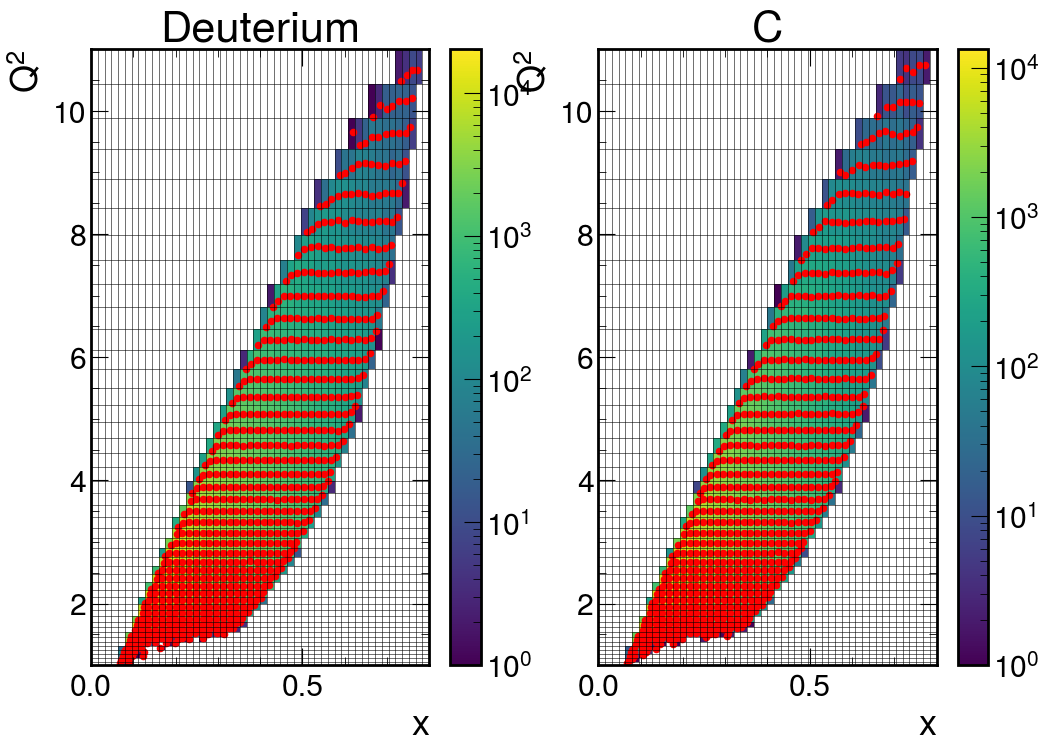

In [24]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,8))
deuterium_2d_counts, deuterium_x_bins, deuterium_Q2_bins , im1 = ax1.hist2d(np.array(dataframes["LD2"].x),
                                                                            np.array(dataframes["LD2"].Q2),
                                                                            bins=(x_bin_edges, Q2_bin_edges),
                                                                            norm=mcolors.LogNorm())
fig.colorbar(im1, ax=ax1)
ax1.set_xlabel("x")
ax1.set_ylabel("$Q^{2}$")
ax1.set_title("Deuterium")
deuterium_2d_count_errors = np.sqrt(deuterium_2d_counts)

ax1.scatter(deuterium_x_centroids,
            deuterium_Q2_centroids,
            color = 'r',
            s = 20)
for bin_edge in Q2_bin_edges:
    ax1.axhline(y = bin_edge, color = 'black', linestyle='solid', alpha = .8, linewidth = 0.5)
for bin_edge in x_bin_edges:
    ax1.axvline(x = bin_edge, color = 'black', linestyle='solid', alpha = .8, linewidth = 0.5)

solid_2d_counts, solid_x_bins, solid_Q2_bins , im2 = ax2.hist2d(np.array(dataframes[solid_target].x),
                                                                np.array(dataframes[solid_target].Q2),
                                                                bins=(x_bin_edges, Q2_bin_edges),
                                                                norm=mcolors.LogNorm())
# ax1.plot(x_values, Q2_from_W, color='black')
# ax1.plot(x_values, Q2_from_y, color='black')
fig.colorbar(im2, ax=ax2)
ax2.set_xlabel("x")
ax2.set_ylabel("$Q^{2}$")
ax2.set_title("{solid}".format(solid=solid_target))

solid_2d_count_errors = np.sqrt(solid_2d_counts)

ax2.scatter(solid_x_centroids,
            solid_Q2_centroids,
            color = 'r',
            s = 20)
# ax2.plot(x_values, Q2_from_W, color='black')
# ax2.plot(x_values, Q2_from_y, color='black')
for bin_edge in Q2_bin_edges:
    ax2.axhline(y = bin_edge, color = 'black', linestyle='solid', alpha = .8, linewidth = 0.5)
for bin_edge in x_bin_edges:
    ax2.axvline(x = bin_edge, color = 'black', linestyle='solid', alpha = .8, linewidth = 0.5)

In [25]:
corrections_dict = {"C":OpenCorrections("/media/miguel/Elements_2024/CLAS_data/C/radiative_corrections/clasC12_geometric.out"), "LD2":OpenCorrections("/media/miguel/Elements_2024/CLAS_data/C/radiative_corrections/clasd2_geometric.out")}
corrections_centroids_dict = {"C":OpenCorrections("/media/miguel/Elements_2024/CLAS_data/C/radiative_corrections/clasC12_centroids.out"), "LD2":OpenCorrections("/media/miguel/Elements_2024/CLAS_data/C/radiative_corrections/clasd2_centroids.out")}

In [26]:
corrections_dict["C"]["x_bin_center"] = x_bin_centers[np.digitize(corrections_dict["C"]["x"], x_bin_edges)-1]
corrections_dict["C"]["Q2_bin_center"] = Q2_bin_centers[np.digitize(corrections_dict["C"]["Q2"], Q2_bin_edges)-1]
corrections_dict["LD2"]["x_bin_center"] = x_bin_centers[np.digitize(corrections_dict["LD2"]["x"], x_bin_edges)-1]
corrections_dict["LD2"]["Q2_bin_center"] = Q2_bin_centers[np.digitize(corrections_dict["LD2"]["Q2"], Q2_bin_edges)-1]

In [27]:
corrections_centroids_dict["C"]["x_bin_center"] = x_bin_centers[np.digitize(corrections_centroids_dict["C"]["x"], x_bin_edges)-1]
corrections_centroids_dict["C"]["Q2_bin_center"] = Q2_bin_centers[np.digitize(corrections_centroids_dict["C"]["Q2"], Q2_bin_edges)-1]
corrections_centroids_dict["LD2"]["x_bin_center"] = x_bin_centers[np.digitize(corrections_centroids_dict["LD2"]["x"], x_bin_edges)-1]
corrections_centroids_dict["LD2"]["Q2_bin_center"] = Q2_bin_centers[np.digitize(corrections_centroids_dict["LD2"]["Q2"], Q2_bin_edges)-1]

In [28]:
merged_df = bin_dataframes["C"].merge(
    corrections_dict["C"][["x_bin_center", "Q2_bin_center", "C_cor", "Sig_Born", "Sig_Rad"]],
    on=["x_bin_center", "Q2_bin_center"],
    how="left"
)
bin_dataframes["C"] = merged_df
merged_df = bin_dataframes["C"].merge(
    corrections_centroids_dict["C"][["x_bin_center", "Q2_bin_center", "C_cor", "Sig_Born", "Sig_Rad"]].rename(columns={"C_cor": "C_cor_centroid", "Sig_Born": "Sig_Born_centroid", "Sig_Rad": "Sig_Rad_centroid"}),
    on=["x_bin_center", "Q2_bin_center"],
    how="left"
)
bin_dataframes["C"] = merged_df

merged_df_deuterium = bin_dataframes["LD2"].merge(
    corrections_dict["LD2"][["x_bin_center", "Q2_bin_center", "C_cor", "Sig_Born", "Sig_Rad"]],
    on=["x_bin_center", "Q2_bin_center"],
    how="left"
)
bin_dataframes["LD2"] = merged_df_deuterium
merged_df_deuterium = bin_dataframes["LD2"].merge(
    corrections_centroids_dict["LD2"][["x_bin_center", "Q2_bin_center", "C_cor", "Sig_Born", "Sig_Rad"]].rename(columns={"C_cor": "C_cor_centroid", "Sig_Born": "Sig_Born_centroid", "Sig_Rad": "Sig_Rad_centroid"}),
    on=["x_bin_center", "Q2_bin_center"],
    how="left"
)
bin_dataframes["LD2"] = merged_df_deuterium




In [29]:
def DivideWithErrors(numerator, numerator_err, divisor, divisor_err):
    ratio = np.zeros_like(numerator)
    ratio_err = np.zeros_like(numerator)
    zero_mask = (numerator > 0) & (divisor > 0)
    ratio[zero_mask] = numerator[zero_mask] / divisor[zero_mask]
    ratio_err[zero_mask] = ratio[zero_mask] * np.sqrt( ( numerator_err[zero_mask]/numerator[zero_mask] )**2 + ( divisor_err[zero_mask]/divisor[zero_mask] )**2)
    ratio[~zero_mask] = None
    ratio_err[~zero_mask] = None
    return ratio, ratio_err

In [30]:
def normalize_2dhist_and_errors(x_edges, y_edges, nonnormalized_hist, nonnormalized_errors):
    x_widths = np.diff(x_edges)
    y_widths = np.diff(y_edges)
    bin_areas = np.outer(x_widths, y_widths)
    total_counts = np.sum(nonnormalized_hist)
    normalized_counts = nonnormalized_hist / (total_counts * bin_areas)
    normalized_errors = nonnormalized_errors / (total_counts * bin_areas)
    return normalized_counts, normalized_errors
def normalize_to_absolute_cross_section(x_edges, y_edges, nonnormalized_hist, nonnormalized_errors, target):
    x_widths = np.diff(x_edges)
    y_widths = np.diff(y_edges)
    bin_areas = np.outer(x_widths, y_widths)
    num_incident_electrons = num_incident_electrons_per_target[target]
    normalized_counts = nonnormalized_hist / (num_incident_electrons * bin_areas)
    normalized_errors = nonnormalized_errors / (num_incident_electrons * bin_areas)
    return normalized_counts, normalized_errors

[[ 0.      0.      0.     ...  0.      0.      0.    ]
 [ 0.      0.      0.     ...  0.      0.      0.    ]
 [ 0.      0.      0.     ...  0.      0.      0.    ]
 ...
 [ 0.      0.      0.     ...  4.0296 12.0936  8.0688]
 [ 0.      0.      0.     ...  0.      0.      2.0174]
 [ 0.      0.      0.     ...  0.      0.      0.    ]]
[[ 0.      0.      0.     ...  0.      0.      0.    ]
 [ 0.      0.      0.     ...  0.      0.      0.    ]
 [ 0.      0.      0.     ...  0.      0.      0.    ]
 ...
 [ 0.      0.      0.     ...  4.0292 12.0948  8.0688]
 [ 0.      0.      0.     ...  0.      0.      2.0174]
 [ 0.      0.      0.     ...  0.      0.      0.    ]]
[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  6. 13.  9.]
 [ 0.  0.  0. ...  0.  0.  6.]
 [ 0.  0.  0. ...  0.  0.  0.]]
[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  6. 13.  9.]
 [ 0.  

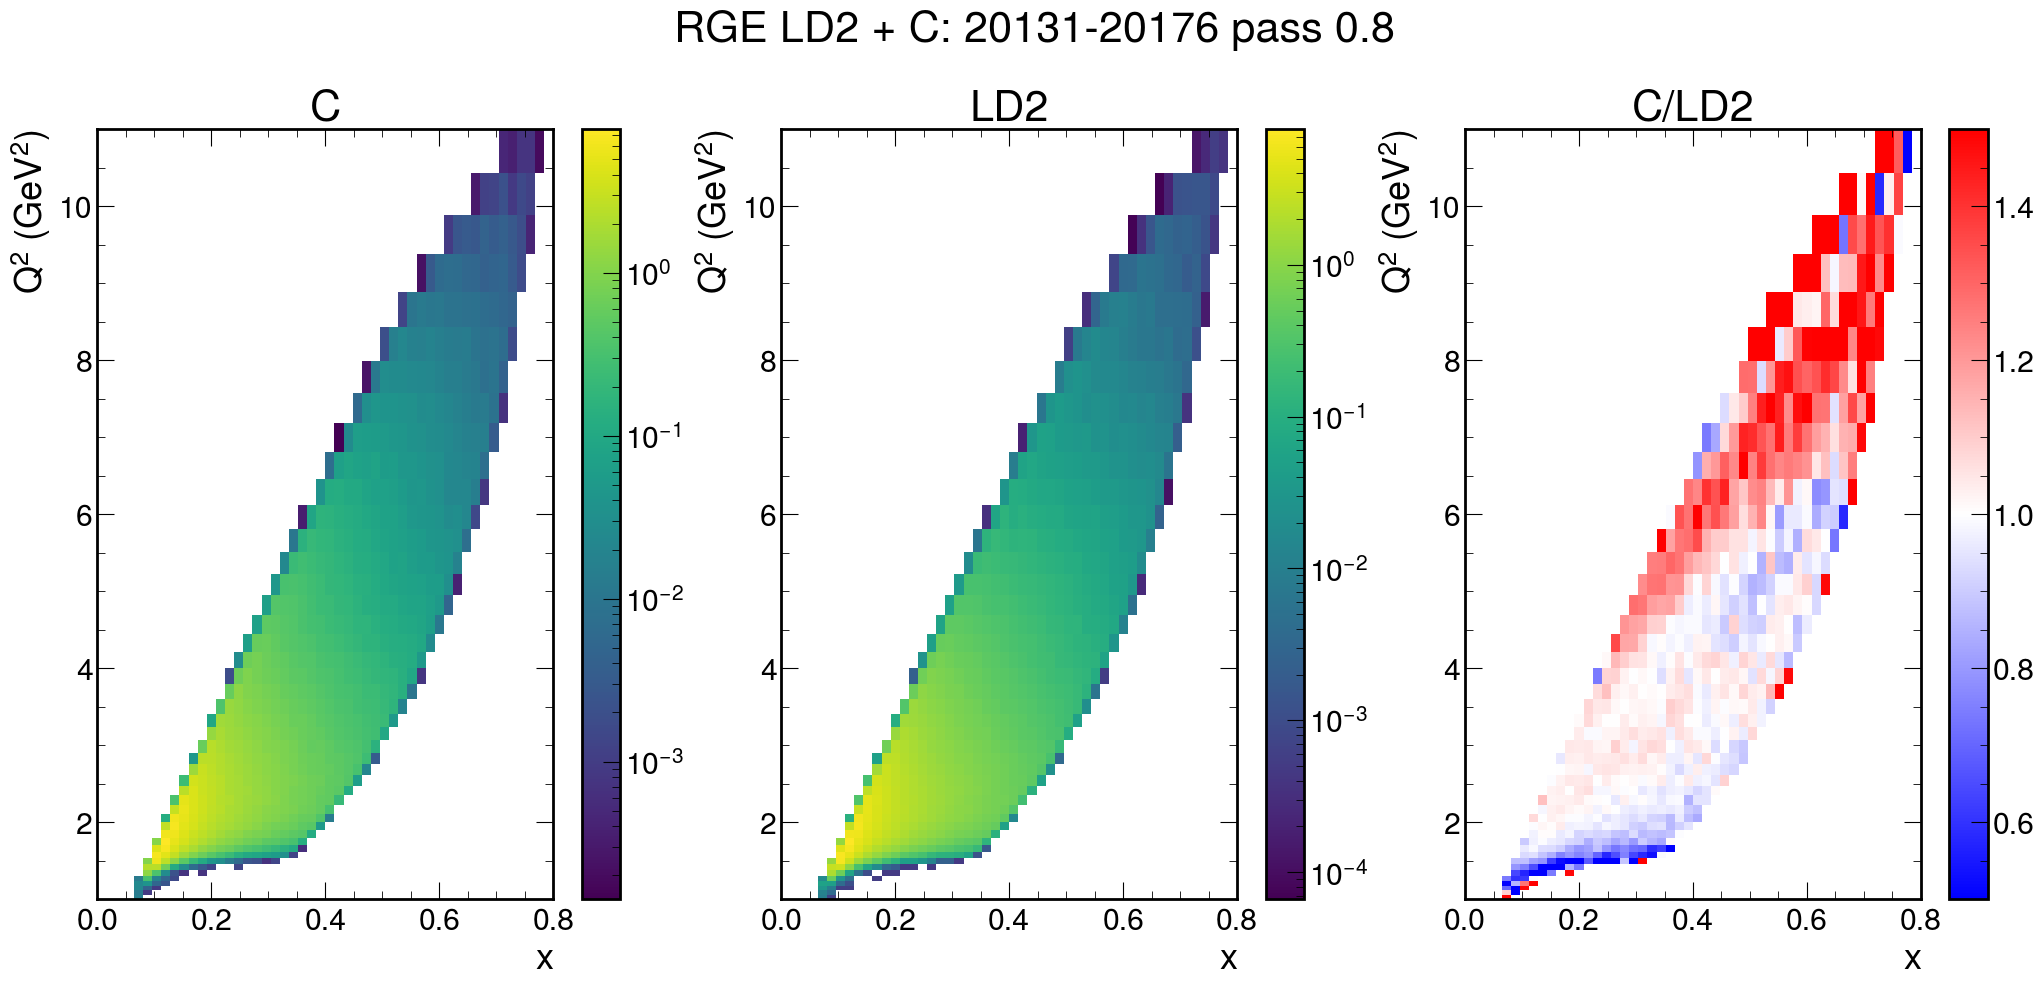

In [31]:
normalized_cross_sections, normalized_cross_sections_errors = {}, {}
fig, axs = plt.subplots(1,3, figsize=(25,10))

for i, (target_name, target_data) in enumerate(dataframes.items()):
    bin_counts_df = pd.DataFrame({
        "x_bin_center": np.repeat(x_bin_centers, len(Q2_bin_centers)),
        "Q2_bin_center": np.tile(Q2_bin_centers, len(x_bin_centers)),
    })
    plt.sca(axs[i])
    
    nonnormalized_cross_sections, _, _ = np.histogram2d(
        target_data.x,
        target_data.Q2,
        bins=(x_bin_edges, Q2_bin_edges)
    )
    nonnormalized_cross_sections_errors = np.sqrt(nonnormalized_cross_sections)

    bin_counts_df["nonnormalized_cross_sections"] = nonnormalized_cross_sections.flatten()
    bin_counts_df["nonnormalized_cross_sections_errors"] = nonnormalized_cross_sections_errors.flatten()

    for use_centroids in (True, False):
        corrections_df = corrections_centroids_dict[target_name] if use_centroids else corrections_dict[target_name]

        # Calculating histograms with CC, RC, and RC*CC
        cc, rc, rc_cc, cc_err, rc_err, rc_cc_err = ApplyCorrections(
            Q2_bin_edges,
            x_bin_edges,
            nonnormalized_cross_sections,
            nonnormalized_cross_sections_errors,
            corrections_df
        )
    
        normalized_cross_sections[target_name], normalized_cross_sections_errors[target_name] = normalize_2dhist_and_errors(
            x_bin_edges,
            Q2_bin_edges,
            nonnormalized_cross_sections,
            nonnormalized_cross_sections_errors
        )
    
        normalized_cross_sections_with_rc, normalized_cross_sections_with_rc_errors = normalize_2dhist_and_errors(
            x_bin_edges,
            Q2_bin_edges,
            rc,
            rc_err,
        )
        
    
        normalized_cross_sections_with_rc_cc, normalized_cross_sections_with_rc_cc_errors = normalize_2dhist_and_errors(
            x_bin_edges,
            Q2_bin_edges,
            rc_cc,
            rc_cc_err,
        )

        absolute_cross_sections, absolute_cross_sections_errors = normalize_to_absolute_cross_section(
            x_bin_edges,
            Q2_bin_edges,
            rc_cc,
            rc_cc_err,
            target_name
        )
        if use_centroids:
            bin_counts_df["normalized_cross_sections_centroids"] = normalized_cross_sections[target_name].flatten()
            bin_counts_df["normalized_cross_sections_errors_centroids"] = normalized_cross_sections_errors[target_name].flatten()
            bin_counts_df["normalized_cross_sections_with_rc_centroids"] = normalized_cross_sections_with_rc.flatten()
            bin_counts_df["normalized_cross_sections_with_rc_errors_centroids"] = normalized_cross_sections_with_rc_errors.flatten()
            bin_counts_df["normalized_cross_sections_with_rc_cc_centroids"] = normalized_cross_sections_with_rc_cc.flatten()
            bin_counts_df["normalized_cross_sections_with_rc_cc_errors_centroids"] = normalized_cross_sections_with_rc_cc_errors.flatten()
            bin_counts_df["absolute_cross_sections_centroids"] = absolute_cross_sections.flatten()
            bin_counts_df["absolute_cross_sections_errors_centroids"] = absolute_cross_sections_errors.flatten()
        else:
            bin_counts_df["normalized_cross_sections"] = normalized_cross_sections[target_name].flatten()
            bin_counts_df["normalized_cross_sections_errors"] = normalized_cross_sections_errors[target_name].flatten()
            bin_counts_df["normalized_cross_sections_with_rc"] = normalized_cross_sections_with_rc.flatten()
            bin_counts_df["normalized_cross_sections_with_rc_errors"] = normalized_cross_sections_with_rc_errors.flatten()
            bin_counts_df["normalized_cross_sections_with_rc_cc"] = normalized_cross_sections_with_rc_cc.flatten()
            bin_counts_df["normalized_cross_sections_with_rc_cc_errors"] = normalized_cross_sections_with_rc_cc_errors.flatten()
            bin_counts_df["absolute_cross_sections"] = absolute_cross_sections.flatten()
            bin_counts_df["absolute_cross_sections_errors"] = absolute_cross_sections_errors.flatten()

    merged_df = bin_dataframes[target_name].merge(
        bin_counts_df,
        on=["x_bin_center", "Q2_bin_center"],
        how="left"
    )
    bin_dataframes[target_name] = merged_df

    
    plt.hist2d(
        target_data.x,
        target_data.Q2,
        bins=(x_bin_edges, Q2_bin_edges),
        norm = mcolors.LogNorm(),
        density=True
    )

    plt.xlabel("x")
    plt.ylabel("$Q^2~ (GeV^2)$")
    plt.title(target_name)
    plt.colorbar()

plt.sca(axs[2])
ratio_hist, ratio_hist_err = DivideWithErrors(
    numerator = normalized_cross_sections[solid_target],
    numerator_err = normalized_cross_sections_errors[solid_target],
    divisor = normalized_cross_sections["LD2"],
    divisor_err = normalized_cross_sections_errors["LD2"]
)
plt.hist2d(
    np.ravel(x_padded),
    np.ravel(Q2_padded),
    weights=np.ravel(ratio_hist),
    bins=(x_bin_edges, Q2_bin_edges),
    norm=mcolors.Normalize(0.5, 1.5), cmap=colormaps['bwr']
)

plt.xlabel("x")
plt.ylabel("$Q^2~ (GeV^2)$")  
plt.title(f"{solid_target}/LD2")
plt.suptitle(plot_title, y=1.)
plt.colorbar()
plt.show()

In [72]:
x_widths = np.diff(x_bin_edges)
print(x_widths)
    # y_widths = np.diff(y_edges)
    # bin_areas = np.outer(x_widths, y_widths)

[0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016
 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016
 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016
 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016 0.016
 0.016 0.016]


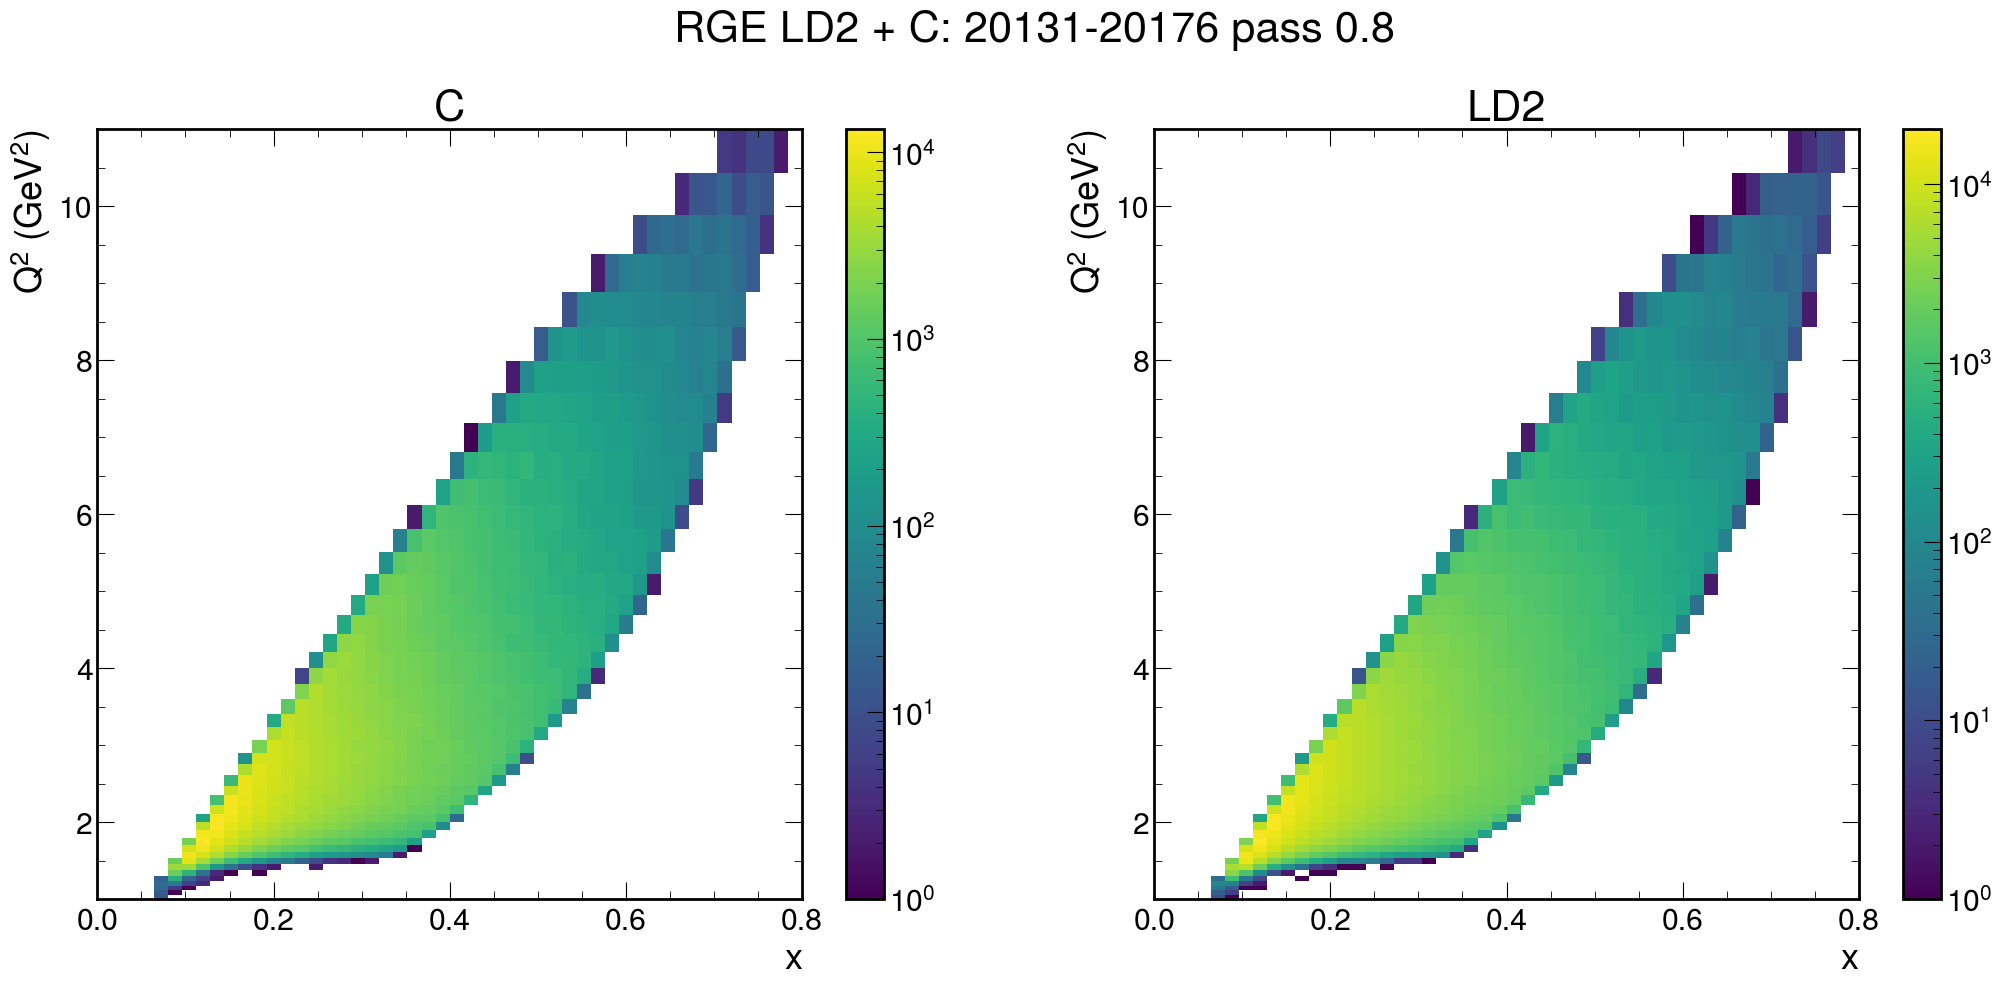

In [32]:
fig, axs = plt.subplots(1,2, figsize=(25,10))

for i, (target_name, target_data) in enumerate(dataframes.items()):
    plt.sca(axs[i])
    

    
    plt.hist2d(
        target_data.x,
        target_data.Q2,
        bins=(x_bin_edges, Q2_bin_edges),
        norm = mcolors.LogNorm(),
        # density=True
    )

    plt.xlabel("x")
    plt.ylabel("$Q^2~ (GeV^2)$")
    plt.title(target_name)
    plt.colorbar()

plt.xlabel("x")
plt.ylabel("$Q^2~ (GeV^2)$")  
plt.suptitle(plot_title, y=1.)
plt.show()

In [33]:
Q2_binning = np.arange(1, 12, 1)
plot_colors = list(plt.rcParams["axes.prop_cycle"])
plot_labels = []
plot_labels_used = []
for i in range(len(Q2_binning)-1):
    plot_labels.append(f"{Q2_binning[i]} < $Q^2$ < {Q2_binning[i+1]}")
    plot_labels_used.append(False)

(0.4, 1.2)

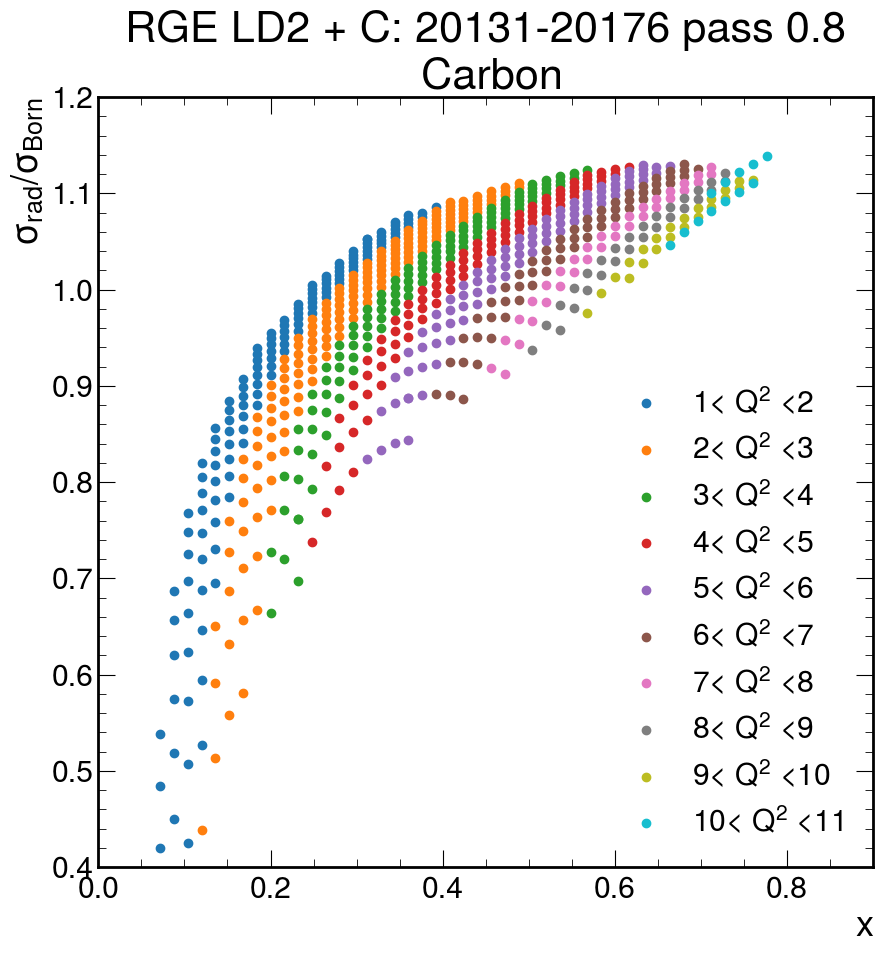

In [34]:
for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])
    
    corrections = bin_dataframes["C"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")
    
    
    plt.scatter(corrections["x_bin_center"], corrections["Sig_Born"]/corrections["Sig_Rad"], label=f"{round(Q2_range[0],2)}< $Q^2$ <{round(Q2_range[1],2)}")
plt.legend()
plt.xlabel("x")
plt.ylabel("$\sigma_{rad}/\sigma_{Born}$")
plt.title(plot_title+"\n Carbon")
plt.xlim(0, .9)
plt.ylim(.4, 1.2)

(0.4, 1.2)

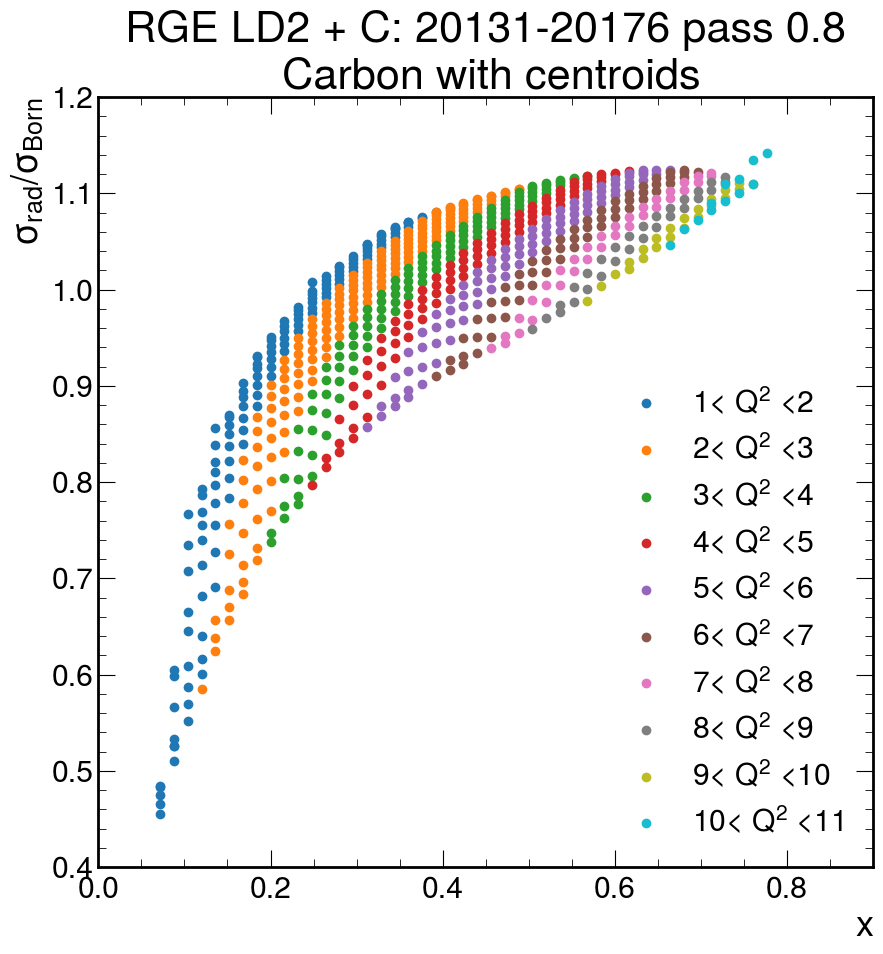

In [35]:
for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])
    
    corrections = bin_dataframes["C"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")
    
    
    plt.scatter(corrections["x_bin_center"], corrections["Sig_Born_centroid"]/corrections["Sig_Rad_centroid"], label=f"{round(Q2_range[0],2)}< $Q^2$ <{round(Q2_range[1],2)}")
plt.legend()
plt.xlabel("x")
plt.ylabel("$\sigma_{rad}/\sigma_{Born}$")
plt.title(plot_title+"\n Carbon with centroids")
plt.xlim(0, .9)
plt.ylim(.4, 1.2)

(0.988, 1.01)

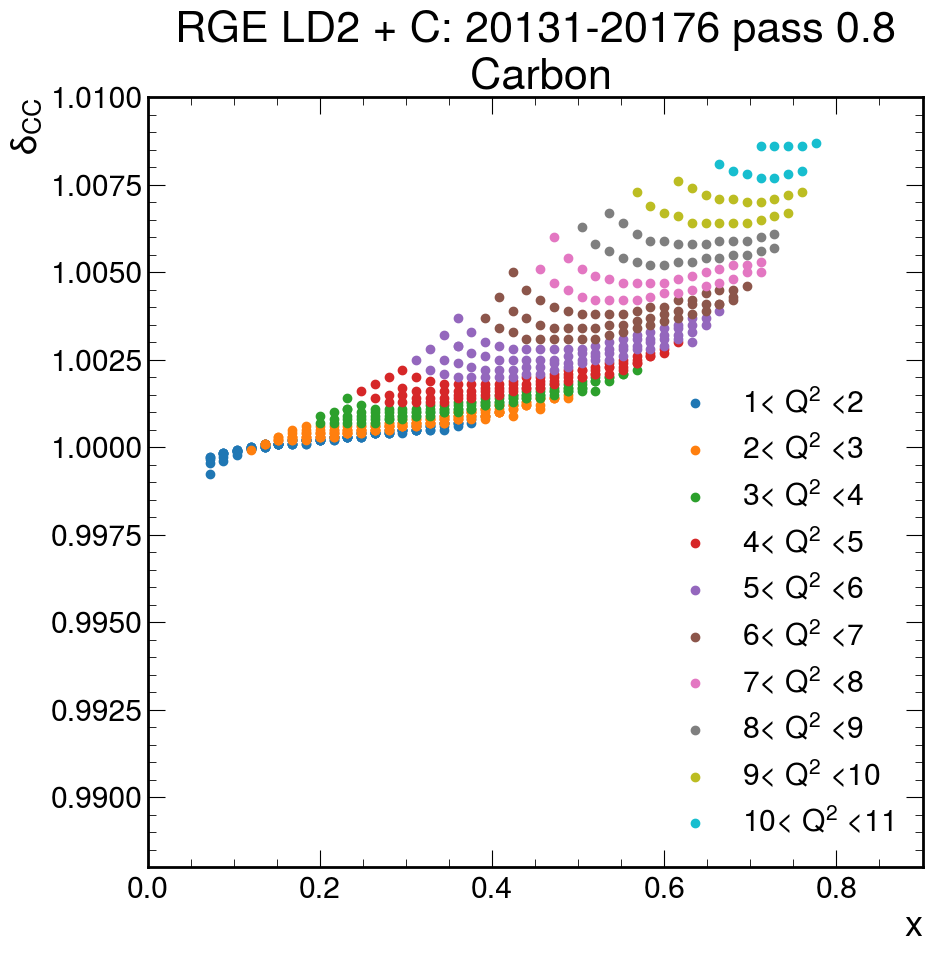

In [36]:
for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])
    
    corrections = bin_dataframes["C"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")
    
    
    plt.scatter(corrections["x_bin_center"], corrections["C_cor"], label=f"{round(Q2_range[0],2)}< $Q^2$ <{round(Q2_range[1],2)}")
plt.legend()
plt.xlabel("x")
plt.ylabel("$\delta_{CC}$")
plt.title(plot_title+"\n Carbon")
plt.xlim(0, .9)
plt.ylim(.988, 1.01)

(0.988, 1.01)

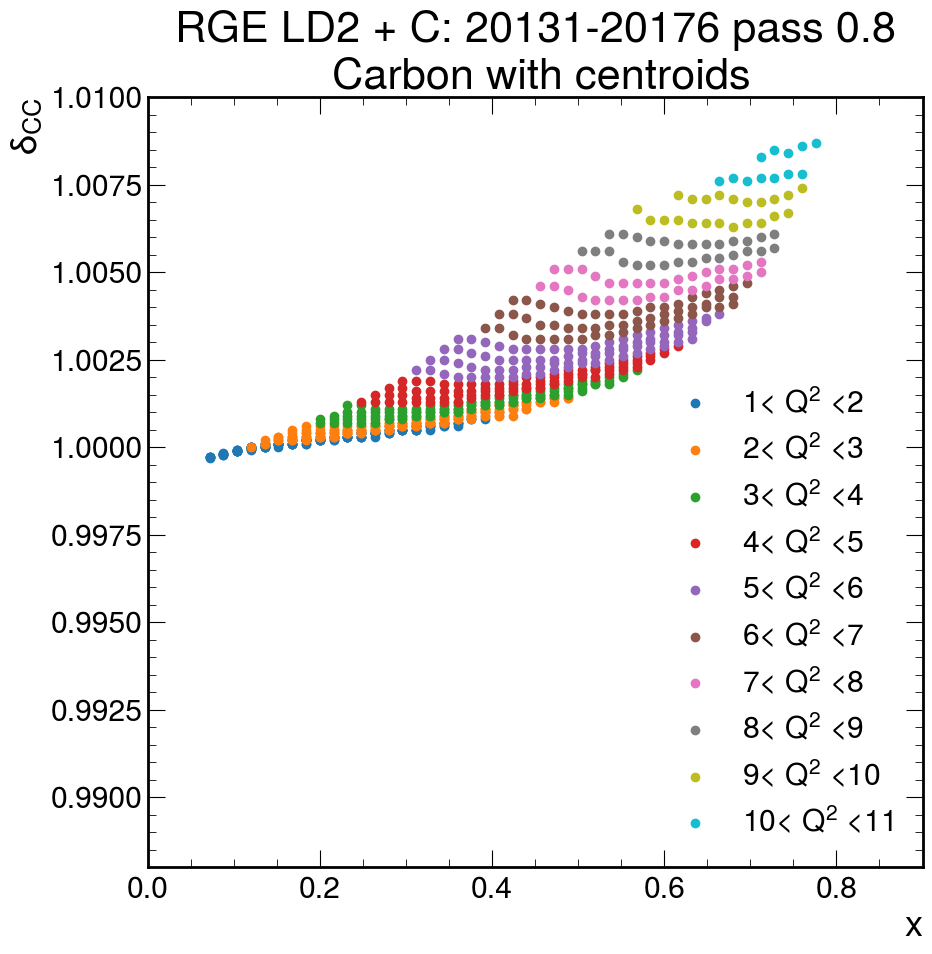

In [37]:
for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])
    
    corrections = bin_dataframes["C"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")
    
    
    plt.scatter(corrections["x_bin_center"], corrections["C_cor_centroid"], label=f"{round(Q2_range[0],2)}< $Q^2$ <{round(Q2_range[1],2)}")
plt.legend()
plt.xlabel("x")
plt.ylabel("$\delta_{CC}$")
plt.title(plot_title+"\n Carbon with centroids")
plt.xlim(0, .9)
plt.ylim(.988, 1.01)

(0.4, 1.2)

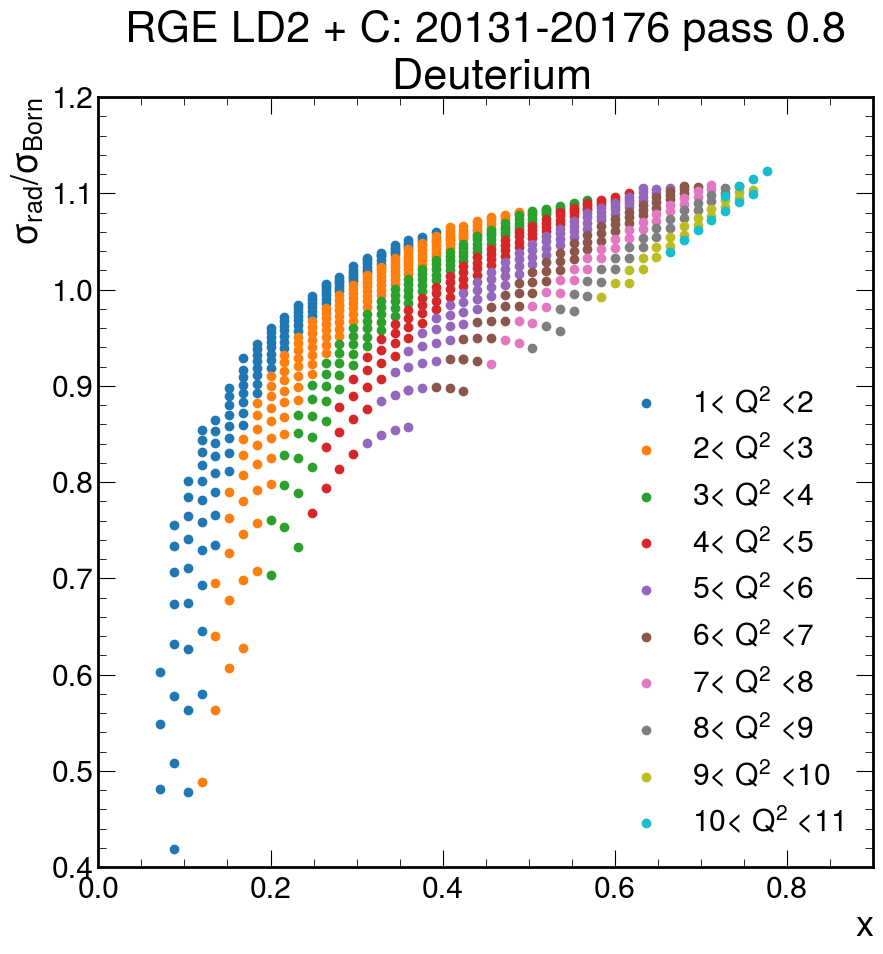

In [38]:
for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])
    
    corrections = bin_dataframes["LD2"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")
    
    
    plt.scatter(corrections["x_bin_center"], corrections["Sig_Born"]/corrections["Sig_Rad"], label=f"{round(Q2_range[0],2)}< $Q^2$ <{round(Q2_range[1],2)}")
plt.legend()
plt.xlabel("x")
plt.ylabel("$\sigma_{rad}/\sigma_{Born}$")
plt.title(plot_title+"\n Deuterium")
plt.xlim(0, .9)
plt.ylim(.4, 1.2)

(0.4, 1.2)

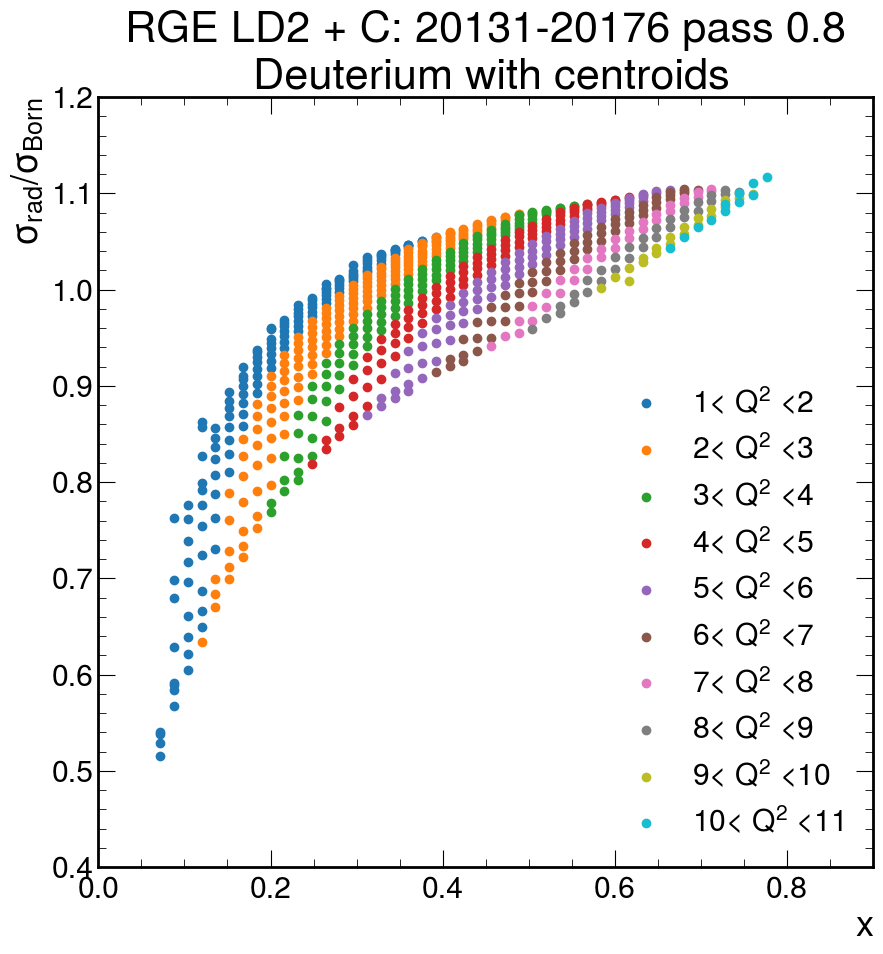

In [39]:
for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])
    
    corrections = bin_dataframes["LD2"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")
    
    
    plt.scatter(corrections["x_bin_center"], corrections["Sig_Born_centroid"]/corrections["Sig_Rad_centroid"], label=f"{round(Q2_range[0],2)}< $Q^2$ <{round(Q2_range[1],2)}")
plt.legend()
plt.xlabel("x")
plt.ylabel("$\sigma_{rad}/\sigma_{Born}$")
plt.title(plot_title+"\n Deuterium with centroids")
plt.xlim(0, .9)
plt.ylim(.4, 1.2)

Text(0.5, 1.0, 'RGE LD2 + C: 20131-20176 pass 0.8\n Deuterium')

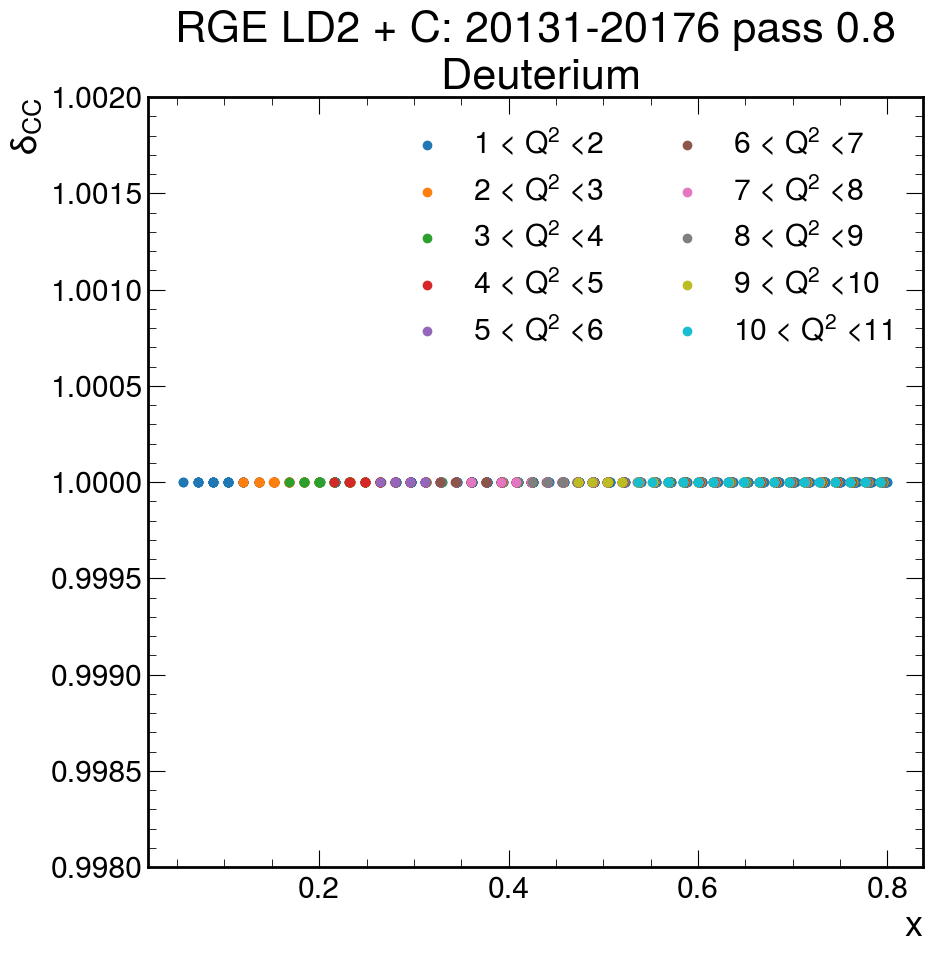

In [40]:
for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])
    
    corrections = corrections_dict["LD2"].query(f"Q2>{Q2_range[0]} & Q2<{Q2_range[1]}") 
    plt.scatter(corrections["x"], corrections["C_cor"], label=f"{round(Q2_range[0],2)} < $Q^2$ <{round(Q2_range[1],2)}")
plt.legend(ncol=2)
plt.xlabel("x")
plt.ylabel("$\delta_{CC}$")
plt.ylim(.998, 1.002)
plt.title(plot_title+"\n Deuterium")

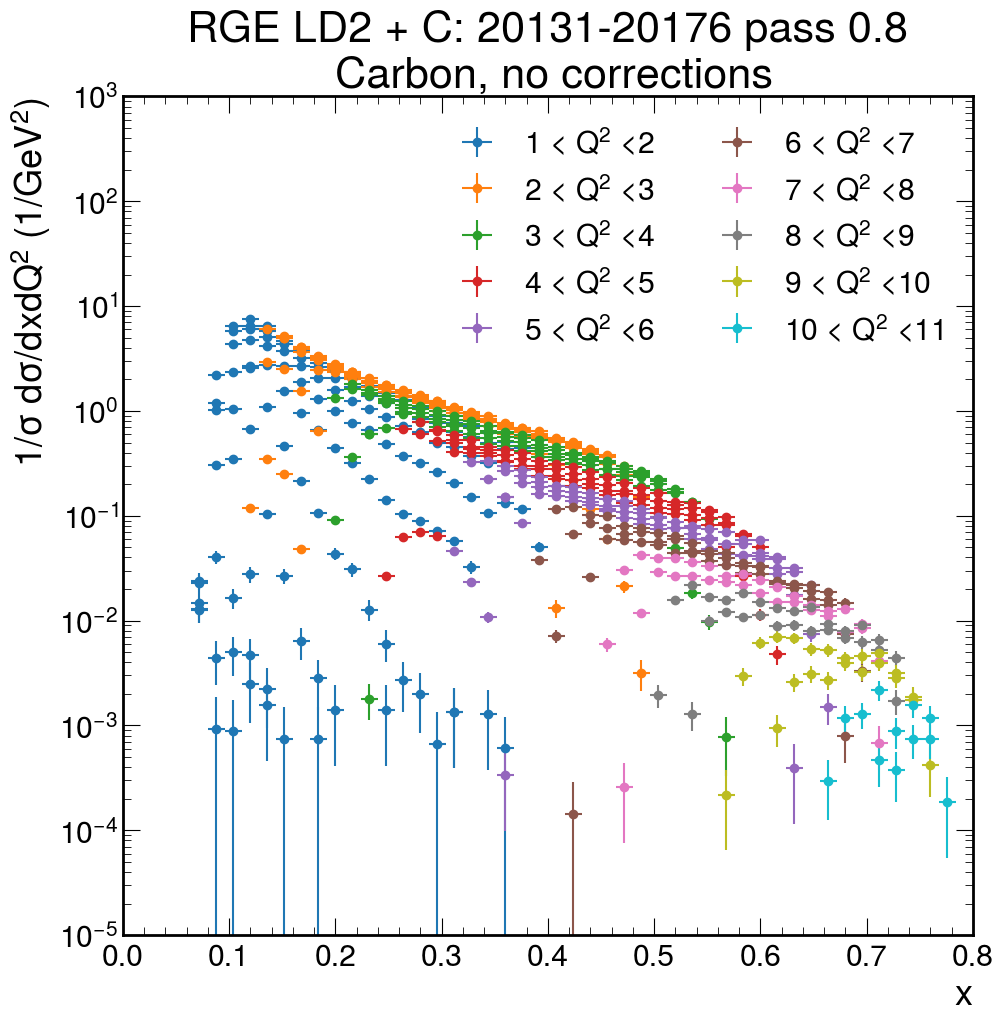

In [41]:
y_low, y_high = 0, 100

for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])

    masked_dataframe = bin_dataframes["C"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")

    bin_widths = x_bin_centers[1] - x_bin_centers[0]

    plot = plt.errorbar(
        masked_dataframe["x_bin_center"],
        masked_dataframe["normalized_cross_sections"],
        xerr = bin_widths/2,
        yerr = masked_dataframe["normalized_cross_sections_errors"],
        label=f"{round(Q2_range[0],2)} < $Q^2$ <{round(Q2_range[1],2)}",
        fmt="o",
    )

plt.xlabel("x")
plt.ylabel(f"$1/\sigma ~d \sigma/dxdQ^2~ (1/GeV^{2})$")
plt.legend(ncol=2, loc='upper right')
plt.tight_layout()
plt.ylim(10**-5,1000)
plt.xlim(0,.8)
plt.title(plot_title+"\n Carbon, no corrections")
plt.yscale('log')

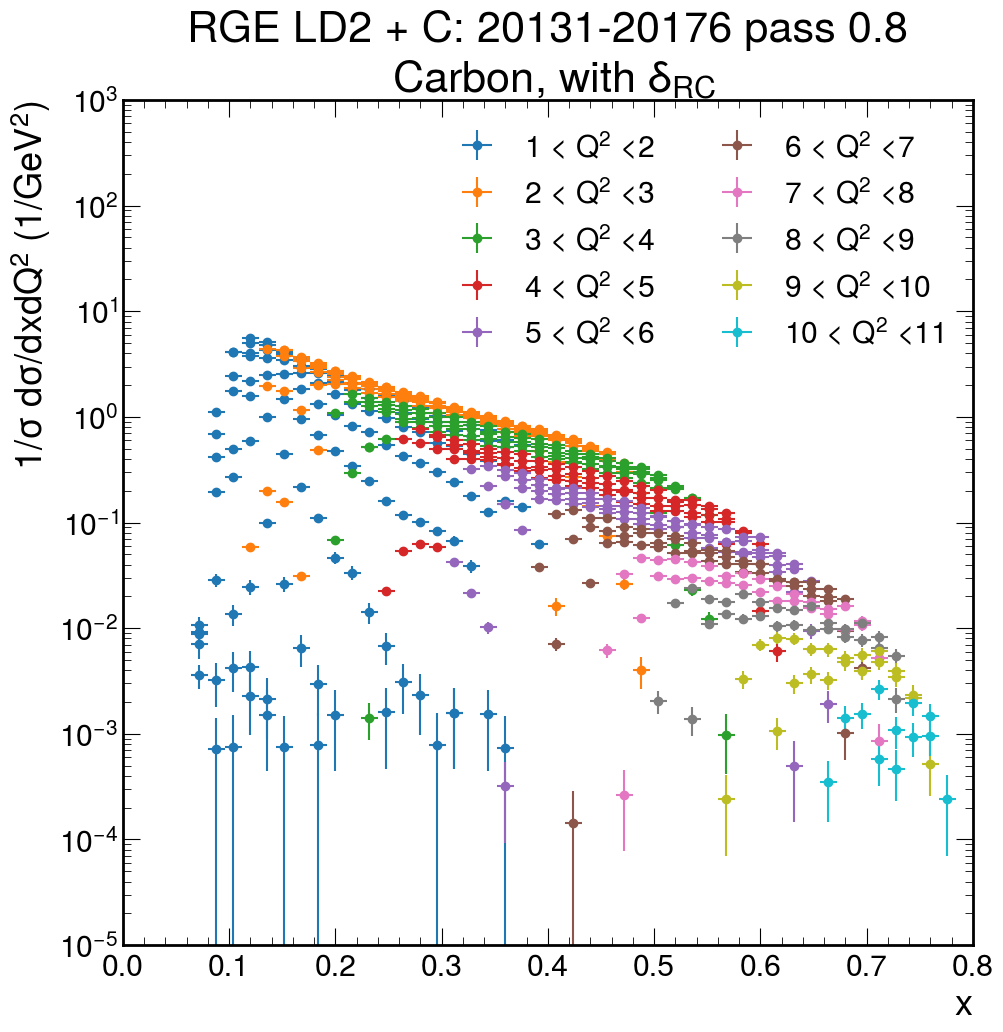

In [42]:
y_low, y_high = 0, 100

for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])

    masked_dataframe = bin_dataframes["C"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")

    bin_widths = x_bin_centers[1] - x_bin_centers[0]

    plot = plt.errorbar(
        masked_dataframe["x_bin_center"],
        masked_dataframe["normalized_cross_sections_with_rc"],
        xerr = bin_widths/2,
        yerr = masked_dataframe["normalized_cross_sections_with_rc_errors"],
        label=f"{round(Q2_range[0],2)} < $Q^2$ <{round(Q2_range[1],2)}",
        fmt="o",
    )

plt.xlabel("x")
plt.ylabel(f"$1/\sigma ~d \sigma/dxdQ^2~ (1/GeV^{2})$")
plt.legend(ncol=2, loc='upper right')
plt.tight_layout()
plt.ylim(10**-5,1000)
plt.xlim(0,.8)
plt.title(plot_title+"\n Carbon, with $\delta_{RC}$")
plt.yscale('log')

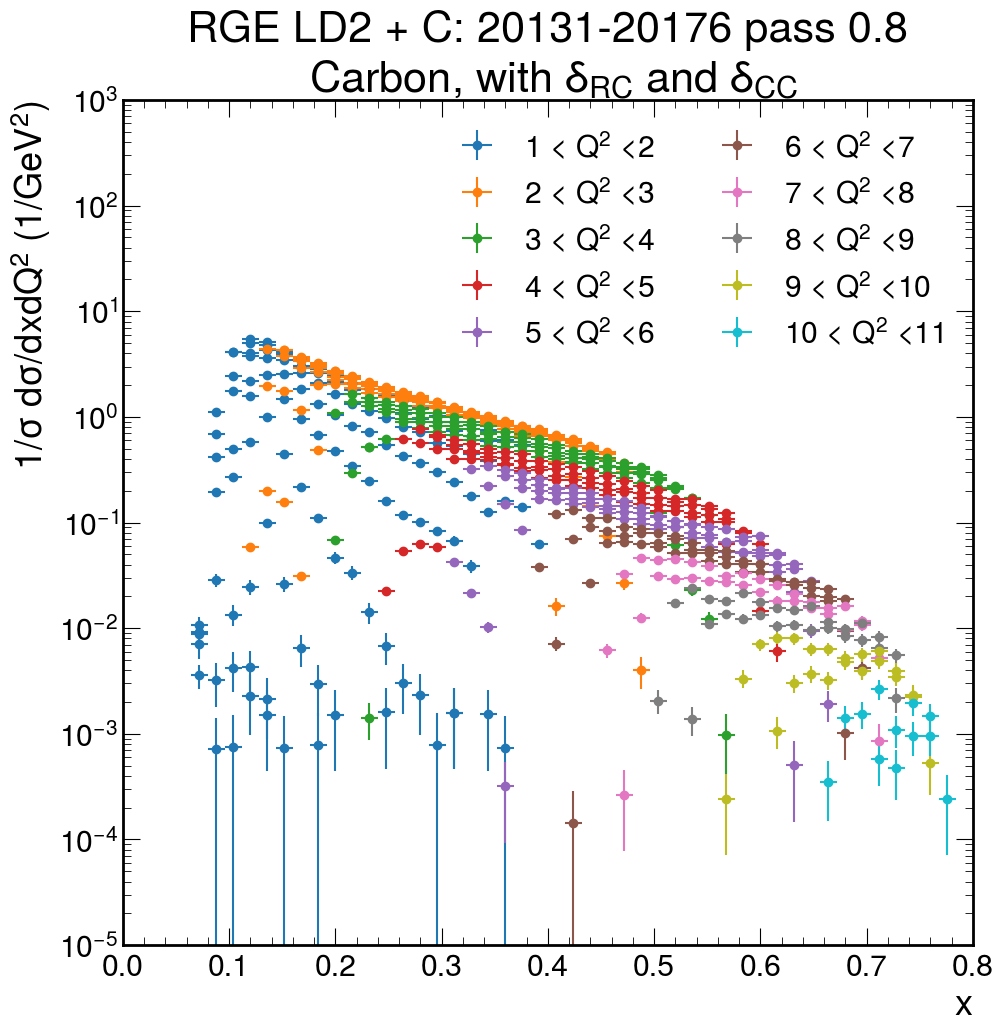

In [43]:
y_low, y_high = 0, 100

for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])

    masked_dataframe = bin_dataframes["C"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")

    bin_widths = x_bin_centers[1] - x_bin_centers[0]

    plot = plt.errorbar(
        masked_dataframe["x_bin_center"],
        masked_dataframe["normalized_cross_sections_with_rc_cc"],
        xerr = bin_widths/2,
        yerr = masked_dataframe["normalized_cross_sections_with_rc_cc_errors"],
        label=f"{round(Q2_range[0],2)} < $Q^2$ <{round(Q2_range[1],2)}",
        fmt="o",
    )

plt.xlabel("x")
plt.ylabel(f"$1/\sigma ~d \sigma/dxdQ^2~ (1/GeV^{2})$")
plt.legend(ncol=2, loc='upper right')
plt.tight_layout()
plt.ylim(10**-5,1000)
plt.xlim(0,.8)
plt.title(plot_title+"\n Carbon, with $\delta_{RC}$ and $\delta_{CC}$")
plt.yscale('log')

In [44]:
print(bin_dataframes["C"]["absolute_cross_sections"])

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2248    0.0
2249    0.0
2250    0.0
2251    0.0
2252    0.0
Name: absolute_cross_sections, Length: 2253, dtype: float64


In [48]:
bin_dataframes["C"]["absolute_cross_sections"] = bin_dataframes["C"]["absolute_cross_sections"] *cm_to_pb/(avogadro*target_densities["C"]*target_thicknesses["C"]/target_atomic_weights["C"])
bin_dataframes["C"]["absolute_cross_sections_errors"] = bin_dataframes["C"]["absolute_cross_sections_errors"] *cm_to_pb/(avogadro*target_densities["C"]*target_thicknesses["C"]/target_atomic_weights["C"])

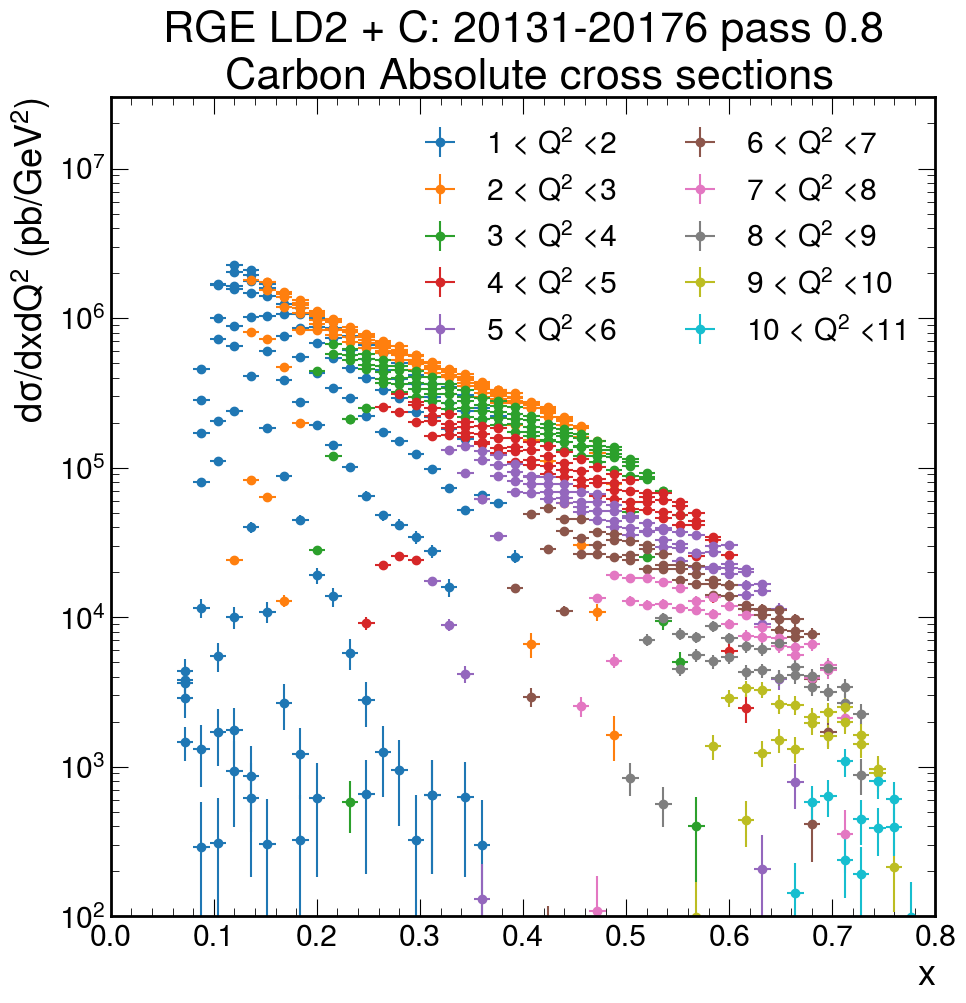

In [71]:
y_low, y_high = 0, 100

for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])

    masked_dataframe = bin_dataframes["C"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")

    bin_widths = x_bin_centers[1] - x_bin_centers[0]

    plot = plt.errorbar(
        masked_dataframe["x_bin_center"],
        masked_dataframe["absolute_cross_sections"],
        xerr = bin_widths/2,
        yerr = masked_dataframe["absolute_cross_sections_errors"],
        label=f"{round(Q2_range[0],2)} < $Q^2$ <{round(Q2_range[1],2)}",
        fmt="o",
    )

plt.xlabel("x")
plt.ylabel(f"$d \sigma/dxdQ^2~ (pb/GeV^{2})$")
plt.legend(ncol=2, loc='upper right')
plt.tight_layout()
plt.ylim(10**2,3*10**7)
plt.xlim(0,.8)
plt.title(plot_title+"\n Carbon Absolute cross sections")
plt.yscale('log')

In [ ]:
y_low, y_high = 0, 100

for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])

    masked_dataframe = bin_dataframes["C"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")

    bin_widths = x_bin_centers[1] - x_bin_centers[0]

    plot = plt.errorbar(
        masked_dataframe["x_bin_center"],
        masked_dataframe["absolute_cross_section"],
        xerr = bin_widths/2,
        yerr = masked_dataframe["absolute_cross_sections_with_rc_cc_errors"],
        label=f"{round(Q2_range[0],2)} < $Q^2$ <{round(Q2_range[1],2)}",
        fmt="o",
    )

plt.xlabel("x")
plt.ylabel(f"$1/\sigma ~d \sigma/dxdQ^2~ (1/GeV^{2})$")
plt.legend(ncol=2, loc='upper right')
plt.tight_layout()
# plt.ylim(10**-5,1000)
plt.xlim(0,.8)
plt.title(plot_title+"\n Carbon, with $\delta_{RC}$ and $\delta_{CC}$")
plt.yscale('log')

In [54]:
print(cm_to_pb/(avogadro*target_densities["C"]*target_thicknesses["C"]/target_atomic_weights["C"]))

78274220340248.36


In [47]:
bin_dataframes["LD2"]["absolute_cross_section"] = bin_dataframes["LD2"]["normalized_cross_sections_with_rc_cc"] *cm_to_pb/(avogadro*target_densities["LD2"]*target_thicknesses["LD2"]/target_atomic_weights["LD2"])
bin_dataframes["LD2"]["absolute_cross_sections_errors"] = bin_dataframes["LD2"]["normalized_cross_sections_with_rc_cc"] *cm_to_pb/(avogadro*target_densities["LD2"]*target_thicknesses["LD2"]/target_atomic_weights["LD2"])

In [48]:
with open("carbon_cross_sections.txt", "a") as f:
    print(bin_dataframes["C"][["x_bin_center","Q2_bin_center", "normalized_cross_sections", "normalized_cross_sections_with_rc_cc", "normalized_cross_sections_errors", "normalized_cross_sections_with_rc_cc_errors"]].query("normalized_cross_sections>0").to_string(index=False), file=f)

In [49]:
with open("deuterium_cross_sections.txt", "a") as f:
    print(bin_dataframes["LD2"][["x_bin_center","Q2_bin_center", "normalized_cross_sections", "normalized_cross_sections_with_rc_cc", "normalized_cross_sections_errors", "normalized_cross_sections_with_rc_cc_errors"]].query("normalized_cross_sections>0").to_string(index=False), file=f)

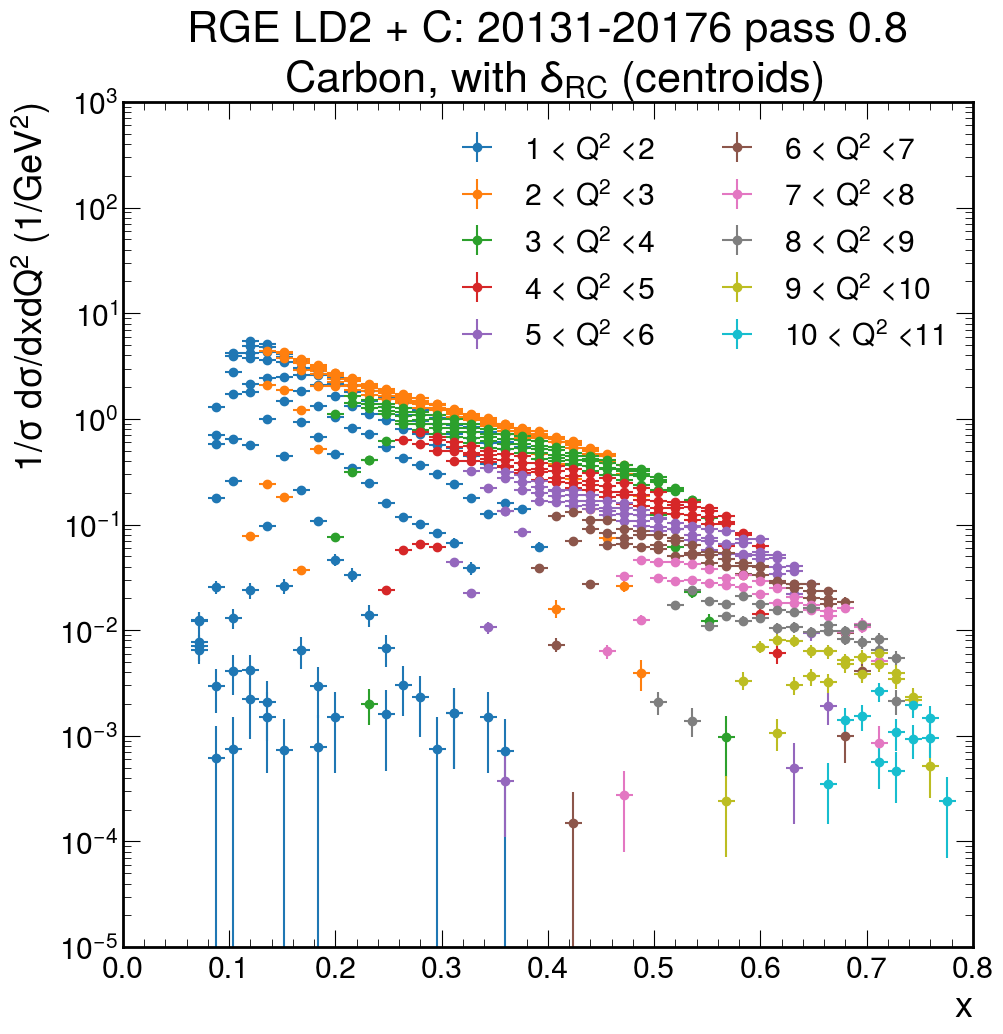

In [49]:
y_low, y_high = 0, 100

for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])

    masked_dataframe = bin_dataframes["C"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")

    bin_widths = x_bin_centers[1] - x_bin_centers[0]

    plot = plt.errorbar(
        masked_dataframe["x_bin_center"],
        masked_dataframe["normalized_cross_sections_with_rc_centroids"],
        xerr = bin_widths/2,
        yerr = masked_dataframe["normalized_cross_sections_with_rc_errors_centroids"],
        label=f"{round(Q2_range[0],2)} < $Q^2$ <{round(Q2_range[1],2)}",
        fmt="o",
    )

plt.xlabel("x")
plt.ylabel(f"$1/\sigma ~d \sigma/dxdQ^2~ (1/GeV^{2})$")
plt.legend(ncol=2, loc='upper right')
plt.tight_layout()
plt.ylim(10**-5,1000)
plt.xlim(0,.8)
plt.title(plot_title+"\n Carbon, with $\delta_{RC}$ (centroids)")
plt.yscale('log')

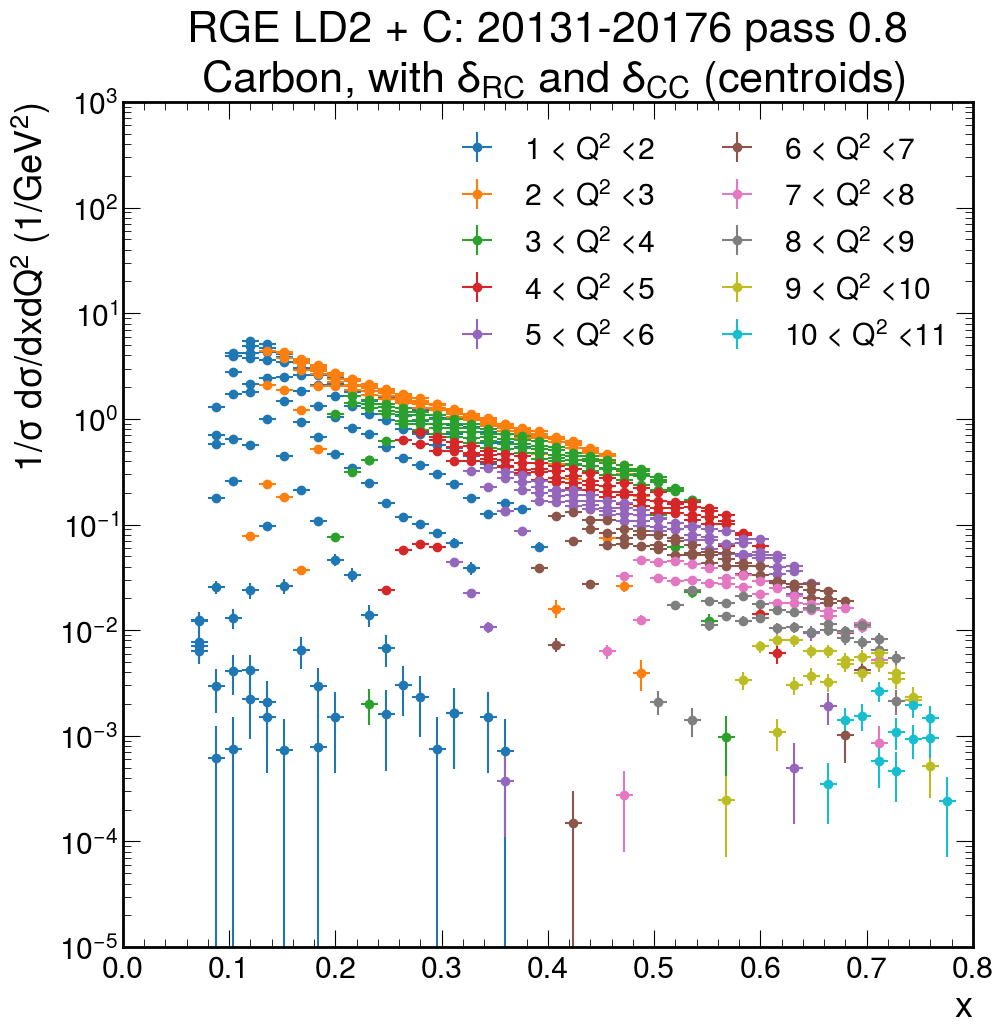

In [49]:
y_low, y_high = 0, 100

for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])

    masked_dataframe = bin_dataframes["C"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")

    bin_widths = x_bin_centers[1] - x_bin_centers[0]

    plot = plt.errorbar(
        masked_dataframe["x_bin_center"],
        masked_dataframe["normalized_cross_sections_with_rc_cc_centroids"],
        xerr = bin_widths/2,
        yerr = masked_dataframe["normalized_cross_sections_with_rc_cc_errors_centroids"],
        label=f"{round(Q2_range[0],2)} < $Q^2$ <{round(Q2_range[1],2)}",
        fmt="o",
    )

plt.xlabel("x")
plt.ylabel(f"$1/\sigma ~d \sigma/dxdQ^2~ (1/GeV^{2})$")
plt.legend(ncol=2, loc='upper right')
plt.tight_layout()
plt.ylim(10**-5,1000)
plt.xlim(0,.8)
plt.title(plot_title+"\n Carbon, with $\delta_{RC}$ and $\delta_{CC}$ (centroids)")
plt.yscale('log')

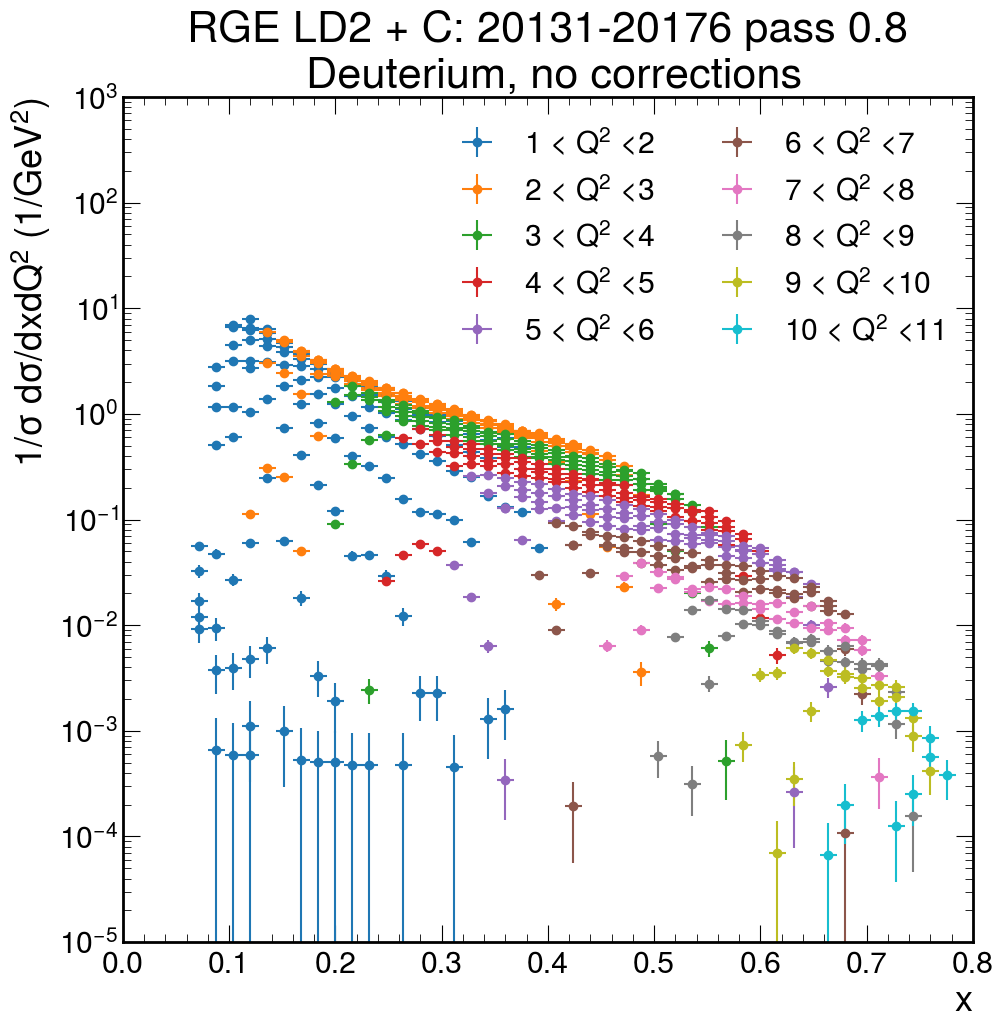

In [50]:
y_low, y_high = 0, 100

for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])

    masked_dataframe = bin_dataframes["LD2"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")

    bin_widths = x_bin_centers[1] - x_bin_centers[0]

    plot = plt.errorbar(
        masked_dataframe["x_bin_center"],
        masked_dataframe["normalized_cross_sections"],
        xerr = bin_widths/2,
        yerr = masked_dataframe["normalized_cross_sections_errors"],
        label=f"{round(Q2_range[0],2)} < $Q^2$ <{round(Q2_range[1],2)}",
        fmt="o",
    )

plt.xlabel("x")
plt.ylabel(f"$1/\sigma ~d \sigma/dxdQ^2~ (1/GeV^{2})$")
plt.legend(ncol=2, loc='upper right')
plt.tight_layout()
plt.ylim(10**-5,1000)
plt.xlim(0,.8)
plt.title(plot_title+"\n Deuterium, no corrections")
plt.yscale('log')

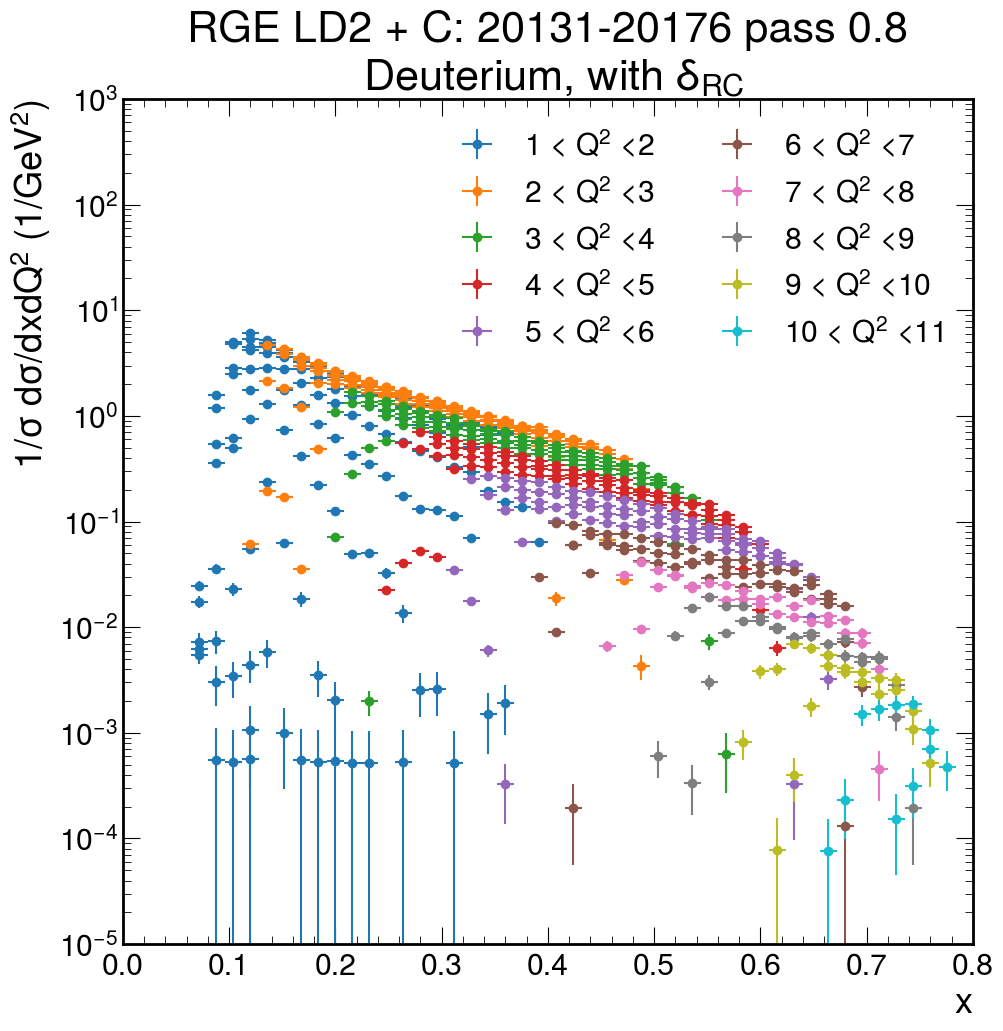

In [51]:
y_low, y_high = 0, 100

for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])

    masked_dataframe = bin_dataframes["LD2"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")

    bin_widths = x_bin_centers[1] - x_bin_centers[0]

    plot = plt.errorbar(
        masked_dataframe["x_bin_center"],
        masked_dataframe["normalized_cross_sections_with_rc"],
        xerr = bin_widths/2,
        yerr = masked_dataframe["normalized_cross_sections_with_rc_errors"],
        label=f"{round(Q2_range[0],2)} < $Q^2$ <{round(Q2_range[1],2)}",
        fmt="o",
    )

plt.xlabel("x")
plt.ylabel(f"$1/\sigma ~d \sigma/dxdQ^2~ (1/GeV^{2})$")
plt.legend(ncol=2, loc='upper right')
plt.tight_layout()
plt.ylim(10**-5,1000)
plt.xlim(0,.8)
plt.title(plot_title+"\n Deuterium, with $\delta_{RC}$")
plt.yscale('log')

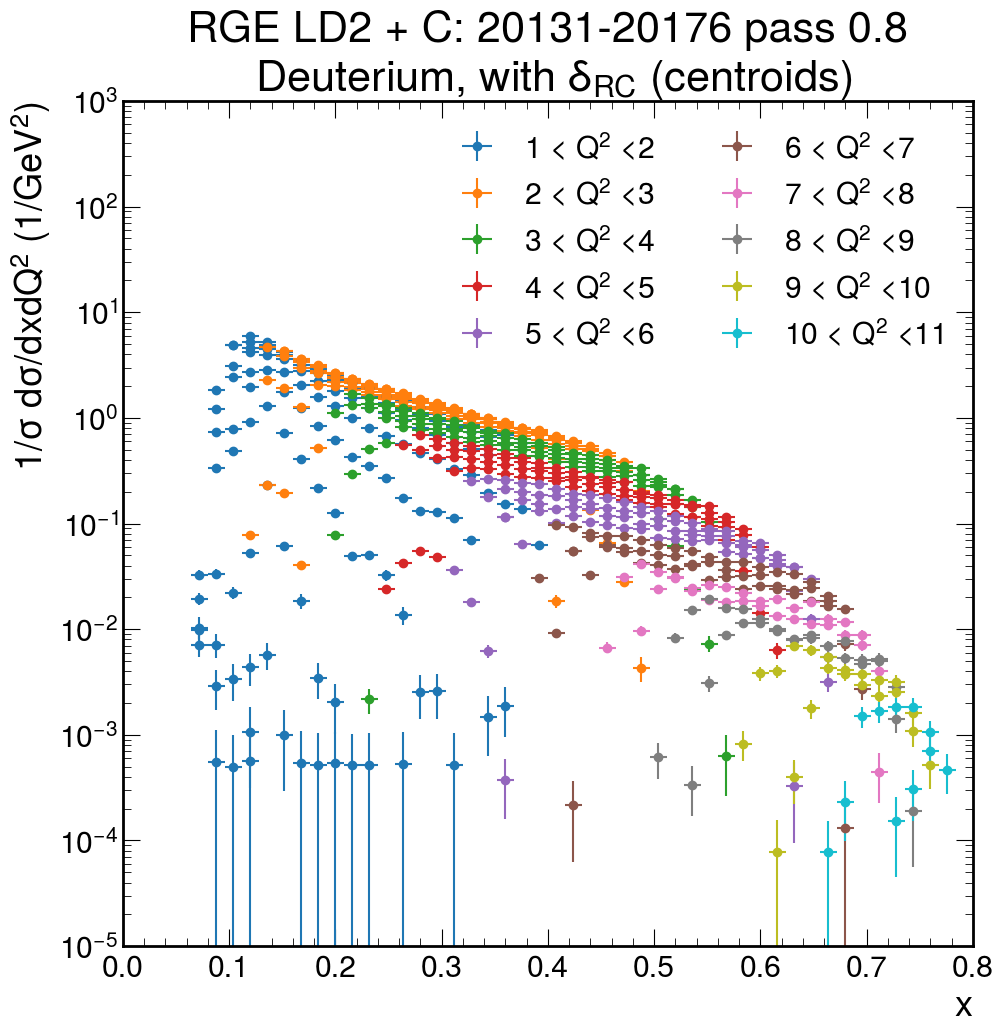

In [52]:
y_low, y_high = 0, 100

for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])

    masked_dataframe = bin_dataframes["LD2"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]} and nonnormalized_cross_sections>0 ")

    bin_widths = x_bin_centers[1] - x_bin_centers[0]

    plot = plt.errorbar(
        masked_dataframe["x_bin_center"],
        masked_dataframe["normalized_cross_sections_with_rc_centroids"],
        xerr = bin_widths/2,
        yerr = masked_dataframe["normalized_cross_sections_with_rc_errors_centroids"],
        label=f"{round(Q2_range[0],2)} < $Q^2$ <{round(Q2_range[1],2)}",
        fmt="o",
    )

plt.xlabel("x")
plt.ylabel(f"$1/\sigma ~d \sigma/dxdQ^2~ (1/GeV^{2})$")
plt.legend(ncol=2, loc='upper right')
plt.tight_layout()
plt.ylim(10**-5,1000)
plt.xlim(0,.8)
plt.title(plot_title+"\n Deuterium, with $\delta_{RC}$ (centroids)")
plt.yscale('log')